# Part 2: Genres and communities and plotting

### *Write about genres and modularity.*

##### *Corresponding text from Week 7 exercise:* ##### 
*Go nuts with an LLM and get all the genres for the nodes in your network*

*Yes, I'm serious. For this one I'd like you to fire up your most powerful thinking model you have access to and get it to write a script to extract genre for all nodes in your network. Some notes to help you*
* *If the node doesn't have an infobox (or if a node's infobox doesn't have a genre it it), just don't assign that node a genre and ignore it in the downstream analysis*
* *Remember to lowercase all genres, also consider simplifying things by mapping rock'n'roll, rock & roll, etc to a single genre.*
* *Remember to test your algorithm well before emplying it, since you're not writing the code yourself, you need to work harder to prove to yourself that it's actually doing what you think it's doing. You should inspect the code to understand what it's actually doing and also test it on the strangest edge-cases you can find. (Can it handle, "The Animals", for example).*
* *The output should be a dictionary mapping artist names to lists of genres (since most artists have multiple genres listed).*

In order to extract the genre information from all the artists pages, I started by loading the network from Github. Each node contains the name of the artist and its corresponding page content.

In [1]:
# Add imports
import urllib
import networkx as nx
import io
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice

# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 484
  Edges: 7676


I converted the directed graph to undirected (as required by *Note: For this and the next exercise, work on the undirected version of the network.*).

In [2]:
network = network.to_undirected()

With the help of an LLM, I defined a function to extract the genre information from each page.

In [12]:
# Helper function to clean the genre text
def clean_genre(genre):
    # Remove reference tags like <ref>...</ref>
    genre = re.sub(r'<ref[^>]*>.*?</ref>', '', genre, flags=re.DOTALL)
    # Remove {{nowrap|...}}
    genre = re.sub(r'\{\{nowrap\|(.*?)\}\}', r'\1', genre)
    # Remove any remaining {{ }}
    genre = re.sub(r'\{\{[^}]*\}\}', '', genre)
    # Remove brackets
    genre = re.sub(r'[\[\]]', '', genre)
    # Clean whitespace
    genre = ' '.join(genre.split())
    # Change to lowercase
    genre = genre.lower().strip()
    
    # Map various rock variants to single genre
    rock_variants = {
        "rock'n'roll": "rock and roll",
        "rock & roll": "rock and roll",
        "rock 'n' roll": "rock and roll",
        "rock n roll": "rock and roll",
        "rock-and-roll": "rock and roll"
    }
    
    if genre in rock_variants:
        return rock_variants[genre]
    
    return genre

# Extract genres list from the wikipedia pages
def extract_genres(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return []
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    if not wikitext:
        return []
    
    # Extract the Infobox musical artist section
    infobox_pattern = r'\{\{Infobox musical artist(.*?)\n\}\}'
    infobox_match = re.search(infobox_pattern, wikitext, re.DOTALL | re.IGNORECASE)
    
    if not infobox_match:
        return []
    
    infobox_content = infobox_match.group(1)
    
    # Extract genre field
    # Look for | genre = followed by content until the next | field
    genre_pattern = r'\|\s*genre\s*=\s*(.*?)(?=\n\||\n\}\})'
    genre_match = re.search(genre_pattern, infobox_content, re.DOTALL | re.IGNORECASE)
    
    if not genre_match:
        return []

    genre_content = genre_match.group(1).strip()
    
    # Parse genres - they can be in various formats
    genres = []
    
    # Remove {{flatlist| and }} wrappers
    genre_content = re.sub(r'\{\{flatlist\|', '', genre_content, flags=re.IGNORECASE)
    genre_content = re.sub(r'\}\}', '', genre_content)
    
    # Remove wiki formatting like [[Genre]] or [[Genre|display text]]
    # Pattern: [[link]] or [[link|text]]
    wiki_links = re.findall(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]', genre_content)
    
    if wiki_links:
        # If we found wiki links, use those
        genres = wiki_links
    else:
        # Otherwise, split by common separators
        # Remove any remaining markup
        genre_content = re.sub(r'<[^>]+>', '', genre_content)
        genre_content = re.sub(r'\*\s*', '', genre_content)
        
        # Split by newlines, commas or bullets
        genre_list = re.split(r'[\n,•]', genre_content)
        genres = [g.strip() for g in genre_list if g.strip()]
    
    # Clean genres
    cleaned_genres = []
    for genre in genres:
        if genre:
            cleaned_genre = clean_genre(genre)
            if cleaned_genre != 'allmusic': # Remove allmusic (discovered during testing)
                cleaned_genres.append(cleaned_genre)
    
    return cleaned_genres

I extracted the genres from each node and added them as a node attribute.

In [13]:
artist_genres = []

for n in network.nodes():
    # Add genres as a list attribute
    genres = extract_genres(network.nodes[n]['content'])
    artist_genres.append(genres)
    network.nodes[n]['genres'] = genres

##### *Corresponding text from Week 7 exercise:* ##### 

*Report the following stats*
* *The number of nodes for which you could find genres*
* *The average number of genres per node*
* *The total number of distinct genres*
* *A histogram showing artist counts for the top 15 genres*

With the help of an LLM, I created a function that generates the above statistics for genres.

In [14]:
# Generate statistics for the nodes with genres
def generate_statistics(nodes_with_genres):
    # 1. Number of nodes with genres
    num_artists_with_genres = len(nodes_with_genres)
    print(f"\n1. Number of artists with genres: {num_artists_with_genres}")
    
    # 2. Average number of genres per node
    total_genres = sum(len(network.nodes[node]['genres']) for node in nodes_with_genres)
    avg_genres = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0
    print(f"2. Average number of genres per artist: {avg_genres:.2f}")
    
    # 3. Total number of distinct genres
    all_genres = set()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        all_genres.update(genres)
    num_distinct_genres = len(all_genres)
    print(f"3. Total number of distinct genres: {num_distinct_genres}")
    
    # 4. Top 15 genres histogram
    genre_counter = Counter()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        genre_counter.update(genres)
    
    top_15 = genre_counter.most_common(15)
    
    print(f"\n4. Top 15 genres:")
    for i, (genre, count) in enumerate(top_15, 1):
        print(f"   {i:2d}. {genre:30s} - {count:3d} artists")
    
    # Create histogram
    if top_15:
        genres_list, counts = zip(*top_15)
        
        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(genres_list)), counts, color='steelblue')
        plt.yticks(range(len(genres_list)), genres_list)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.title('Top 15 Genres by Artist Count', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()  # Highest at top
        
        # Add count labels on bars
        for i, (bar, count) in enumerate(zip(bars, counts)):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'num_artists_with_genres': num_artists_with_genres,
        'avg_genres_per_artist': avg_genres,
        'num_distinct_genres': num_distinct_genres,
        'top_15_genres': top_15
    }

I generate statistics for the nodes which I have extracted genres from.


1. Number of artists with genres: 148
2. Average number of genres per artist: 3.72
3. Total number of distinct genres: 144

4. Top 15 genres:
    1. hard rock                      -  33 artists
    2. rock music                     -  32 artists
    3. pop rock                       -  29 artists
    4. alternative rock               -  24 artists
    5. pop music                      -  22 artists
    6. blues rock                     -  22 artists
    7. soft rock                      -  20 artists
    8. folk rock                      -  14 artists
    9. art rock                       -  13 artists
   10. heavy metal music              -  13 artists
   11. rock and roll                  -  13 artists
   12. country rock                   -  12 artists
   13. southern rock                  -  11 artists
   14. indie rock                     -   9 artists
   15. new wave music                 -   9 artists


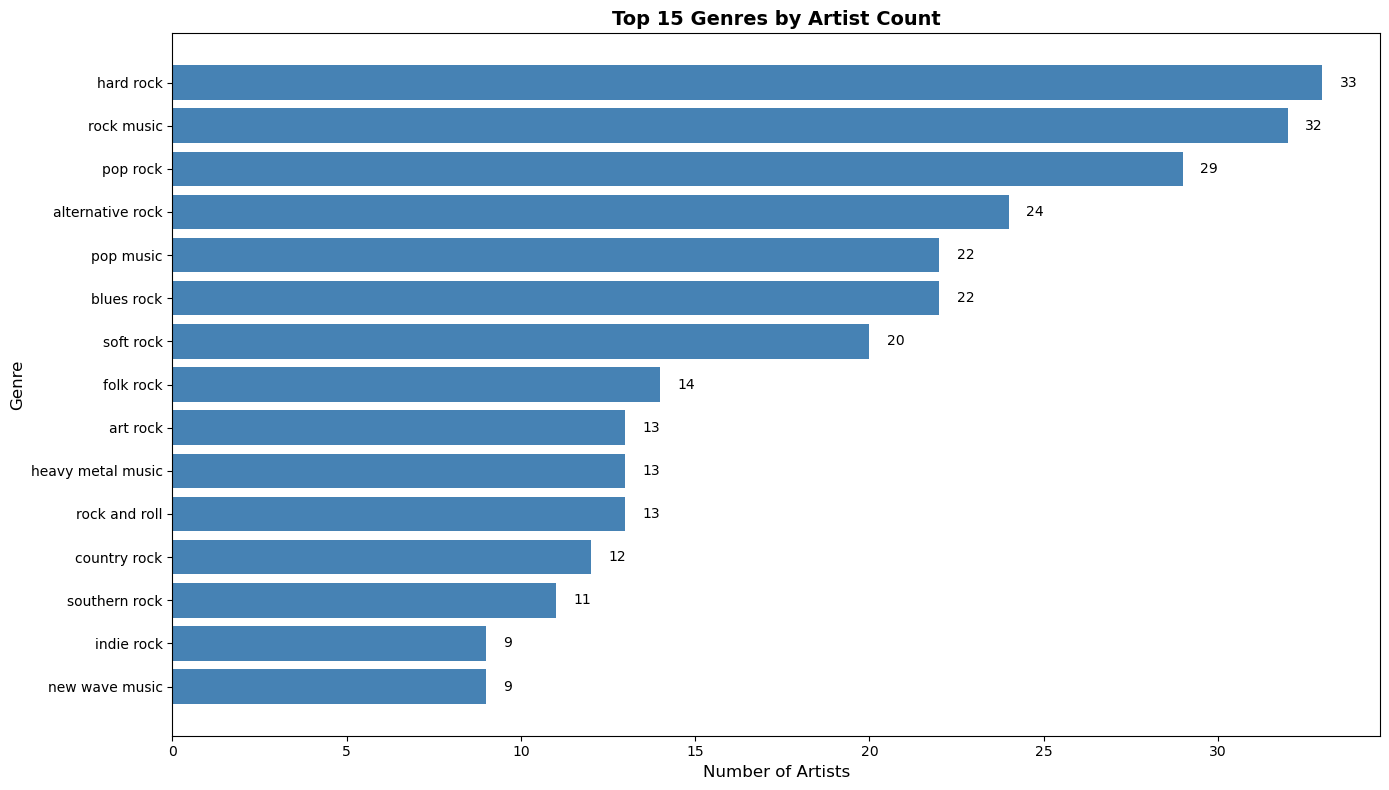

In [15]:
nodes_with_genres = [n for n in network.nodes() if network.nodes[n]['genres']]
stats = generate_statistics(nodes_with_genres)

As expected, the genres are mostly subsets of the rock genre. It can also be observed that Wikipedia considers subgenres of rock but also the broad genres like 'rock music' or 'pop music' when defining the artists. Also an interesting mention is that 'pop music' also appears in the list, so a lot of the artists are actually blending rock and pop music.

For computing modularity, I continue to work with a subnetwork of nodes containing genre information (As required by *Work from the undirected version of the network, keeping only the nodes for which you have genre information.*).

In [16]:
subnetwork = network.subgraph(nodes_with_genres)

##### *Corresponding text from Week 7 exercise:* ##### 

*Explain the concept of modularity in your own words.*

Summarising in my own words what the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity) describes, modularity is a measure of a partition's quality, helping to decide if a community partition is better than another one. The higher is a partition's modularity, the better is the structure of the community it describes. 

Overall, the idea behind modularity's computation is that if there are more links inside a community than you’d expect by chance, then those nodes probably form a real community.

### *Detect the communities, discuss the value of modularity in comparison to the genres.*

##### *Corresponding text from Week 7 exercise:*

*Now create your own partition of the network into genres.*
* *Each node is simply characterized by the first genre in its list of genres.*
* *Each community is the group of nodes that share the same genre.*
* *That's all you need, now calculate the modularity of this division of the network into genres.*
* *Note: Modularity is described in the Network Science book, section 9.4.. Thus, use equation 9.12 in the book to calculate the modularity M of the partition described above. Are the genres good communities?*
*Thinking a bit about the underlying data, a potential issue is the following: Many artists have the genre rock as their first genre in the list (since we started from a list of rock bands). So if rock is a big community, the network won't have very high modularity.*

I first created a partition where each node is characterized by the first genre in its list of genres. Each community is the group of nodes that share the same genre.

In [17]:
# Create a partition based on the first genre in the node's list of genres
def create_first_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = genres[0]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


first_partition = create_first_genre_partition(subnetwork)
for key, members in first_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

{{hlist (1 members):
  - pat benatar

rock music (29 members):
  - lou reed
  - iggy pop
  - kenny loggins
  - dan fogelberg
  - bob seger|bob seger & the silver bullet band
  - tommy james and the shondells
  - ringo starr
  - the pretenders
  - christopher cross
  - the boxtones
  - eddie money
  - robert plant
  - peter frampton
  - joe cocker
  - the beatles
  - the zombies
  - the doobie brothers
  - roy orbison
  - the hollies
  - joan jett|joan jett & the blackhearts
  - bryan adams
  - stevie nicks
  - glenn frey
  - huey lewis and the news
  - little river band
  - neil young
  - grateful dead
  - don henley
  - jimi hendrix

hard rock (13 members):
  - alice cooper
  - the cult
  - joe walsh
  - ted nugent
  - new york dolls
  - led zeppelin
  - alice cooper (band)
  - april wine
  - deep purple
  - golden earring
  - grand funk railroad
  - black stone cherry
  - the guess who

garage rock revival (1 members):
  - the hives

art rock (3 members):
  - roxy music
  - the velve

I defined a function to compute modularity based on the equation 9.12 from the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly).

In [9]:
# Compute modularity based on the equation
def calculate_modularity(G, partition):
    # Get total number of edges
    L = G.number_of_edges()
    
    # Calculate modularity
    modularity = 0.0
    
    for community, nodes in partition.items():
        # Calculate lc: number of edges inside this community
        lc = 0
        for i, node_i in enumerate(nodes):
            for node_j in nodes[i+1:]:  # Only check pairs once
                if G.has_edge(node_i, node_j):
                    lc += 1
        
        # Calculate dc: sum of degrees of all nodes in this community
        dc = sum(G.degree(node) for node in nodes)
        
        # Add contribution of this community to modularity
        # Q = Σc [lc/L - (dc/2L)²]
        modularity += (lc / L) - (dc / (2 * L)) ** 2
    
    return modularity

The partition created leads to a slightly higher than 0 modularity, so the option of defining communities by the first genre in the list is suboptimal.

In [10]:
print(calculate_modularity(subnetwork, first_partition))

0.05097839038359272


##### *Corresponding text from Week 7 exercise:* ##### 

*What happens to the modularity if you use a random genre from the list genre as the node-label for those nodes with more than one genre listed?*

I continued by checking the modularity obtained for a partition defined by a random genre in the node's list of genres.

In [11]:
import random

# Create a partition based on a random genre from the list
def create_genre_random_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = random.choice(genres)
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


ranodm_partition = create_genre_random_partition(subnetwork)
for key, members in ranodm_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

{{hlist (1 members):
  - pat benatar

proto-punk (1 members):
  - lou reed

hard rock (8 members):
  - alice cooper
  - iggy pop
  - ted nugent
  - eddie money
  - joan jett|joan jett & the blackhearts
  - april wine
  - gary glitter
  - grand funk railroad

garage punk (fusion genre) (1 members):
  - the hives

heavy metal music (7 members):
  - the cult
  - tenacious d
  - judas priest
  - robert plant
  - black sabbath
  - iron maiden
  - chris cornell

art rock (4 members):
  - roxy music
  - the velvet underground
  - arcade fire
  - the alan parsons project

soul music (3 members):
  - kenny loggins
  - little richard
  - tracy chapman

folk music (2 members):
  - dan fogelberg
  - james taylor

country rock (4 members):
  - the band
  - the marshall tucker band
  - charlie daniels
  - neil young

dance-rock (1 members):
  - the fixx

pop rock (7 members):
  - joe walsh
  - the fray
  - the bangles
  - the moody blues
  - glenn frey
  - reo speedwagon
  - bryan ferry

glam rock (

The modularity of the random partition is even closer to 0, so it is worse than choosing the first genre from the genre list as a way to define communities.

In [12]:
print(calculate_modularity(subnetwork, ranodm_partition))

0.020174947177441137


##### *Corresponding text from Week 7 exercise:* ##### 
*Discuss your findings - and decide how you want to settle on a single genre for each band.*

I tested also with the second genre in the list, since I had the assumption that the genres will be slightly less broad but still accurately defining the artist's style. However, on computing the modularity the first genre approach had the highest value. This is because using the second genre splits the communities, resulting in more communities with just 1 or 2 members.

In [13]:
# Create a partition based on the second genre in the node's list of genres
def create_second_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if len(genres)>1:
            # Set the label as the second genre
            labels[node] = genres[1]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


second_partition = create_second_genre_partition(subnetwork)
for key, members in second_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

folk rock (4 members):
  - the lumineers
  - neil young
  - crash test dummies
  - james blunt

proto-punk (2 members):
  - new york dolls
  - the velvet underground

pop rock (9 members):
  - reo speedwagon
  - kaiser chiefs
  - the fray
  - the pretenders
  - air supply
  - glenn frey
  - eddie money
  - herman's hermits
  - the fixx

electronic rock (1 members):
  - depeche mode

album-oriented rock (1 members):
  - little river band

pop music (10 members):
  - the lovin' spoonful
  - the beatles
  - christopher cross
  - edgar winter|the edgar winter group
  - the hollies
  - stevie nicks
  - roy orbison
  - ringo starr
  - kenny loggins
  - donovan

southern rock (3 members):
  - black stone cherry
  - montgomery gentry
  - kings of leon

soft rock (4 members):
  - jim croce
  - the doobie brothers
  - paul mccartney and wings|wings
  - three dog night

garage rock revival (1 members):
  - jack white

rhythm and blues (3 members):
  - mitch ryder
  - little richard
  - chuck berr

In [14]:
print(calculate_modularity(subnetwork, second_partition))

0.012612718932799466


##### *Corresponding text from Week 7 exercise:* ##### 

*Again, work only with the subnetwork of nodes that have at least one genre.*
*Use the Louvain-algorithm to find communities for the network. Report the value of modularity found by the algorithm.*
*What is the modularity of this partitioning of the network? Is it more community-like than the genres? What does this comparison reveal about the communities?*

I continued by creating a partition with the help of the Louvain Community Detection Algorithm.

In [15]:
louvain_partition = nx.community.louvain_communities(subnetwork, seed=123)

# Convert the list to a dictionary to use the same calculate_modularity function defined above
louvain_dict = {i+1: list(members) for i, members in enumerate(louvain_partition)}

for key, members in louvain_dict.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

1 (28 members):
  - the doobie brothers
  - bill haley & his comets
  - eddie money
  - grand funk railroad
  - the big bopper
  - little richard
  - little river band
  - the guess who
  - linda ronstadt
  - roy orbison
  - stevie nicks
  - chris cornell
  - april wine
  - john fogerty
  - kenny loggins
  - thirty seconds to mars
  - joe walsh
  - fats domino
  - air supply
  - don henley
  - peter frampton
  - james taylor
  - bob seger|bob seger & the silver bullet band
  - chubby checker
  - robert plant
  - glenn frey
  - neil young
  - buddy holly

2 (1 members):
  - jim croce

3 (1 members):
  - run-dmc

4 (1 members):
  - tommy james and the shondells

5 (1 members):
  - shakin' stevens

6 (1 members):
  - collective soul

7 (1 members):
  - crash test dummies

8 (29 members):
  - the alan parsons project
  - dan fogelberg
  - the moody blues
  - 10cc
  - the mamas & the papas
  - gary glitter
  - the hollies
  - chuck berry
  - duane eddy
  - bay city rollers
  - manfred mann'

The modularity for the Louvain partition is the highest, defining the partition as optimal.

In [16]:
print(calculate_modularity(subnetwork, louvain_dict))

0.3419361351802508


### *Calculate the matrix D and discuss your findings.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Compare the communities found by your algorithm with the music genres by creating a matrix D with dimension (GxC), where G is the 7 most common genres and C is the 7 most common communities (if there are fewer than 7 communities, that's fine, then just work with the communities you have). We set entry D(i,j) to be the number of nodes that genre i has in common with community j. The matrix D is what we call a confusion matrix.*
*Use the confusion matrix to explain how well the communities you've detected correspond to the genres.*
* *Note: This time, use all the genres associate with each node*
* *Note: If a node is not characterized by any of the 7 most popular genres, just ignore it.*
* *Note: If a node is not part of by any of the 7 largest (or fewer, if you only have fewer) communities, just ignore it.*

I used an LLM to help with creating the confusion matrix D plotting the 7 most common genres against the 7 largest communities.

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns

def create_D_matrix(partition):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Get top 7 genres
    top_genres = [g for g, _ in stats['top_15_genres'][:7]]

    # Get top 7 communities (by size)
    community_sizes = [(idx, len(c)) for idx, c in enumerate(community_list)]
    community_sizes.sort(key=lambda x: x[1], reverse=True)
    top_community_indices = [idx for idx, _ in community_sizes[:7]]
    top_communities = [community_list[idx] for idx in top_community_indices]

    # Map node to its community index
    node_to_community = {}
    for idx in top_community_indices:
        for node in community_list[idx]:
            node_to_community[node] = idx

    # Initialize confusion matrix
    conf_matrix = np.zeros((7, 7), dtype=int)

    # For each node, count genre-community overlap
    for node in subnetwork.nodes():
        genres = subnetwork.nodes[node]['genres']
        if not genres:
            continue
        # Only consider nodes in top communities
        if node not in node_to_community:
            continue
        comm_idx = top_community_indices.index(node_to_community[node])
        # For each genre, if it is in top genres, increment
        for genre in genres:
            if genre in top_genres:
                genre_idx = top_genres.index(genre)
                conf_matrix[genre_idx, comm_idx] += 1

    # Create DataFrame for display
    conf_df = pd.DataFrame(conf_matrix, index=top_genres, columns=[f'Community {list(partition.keys())[i]}' for i in range(7)])
    print("Confusion Matrix (Genres vs Communities):")
    print(conf_df)

    # Interpretation
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Community")
    plt.ylabel("Genre")
    plt.title("Confusion Matrix: Genre vs Community")
    plt.show()

I first checked the confusion matrix for the partition defined by the first genre in the genre list.

Confusion Matrix (Genres vs Communities):
                  Community indie folk  Community hard rock  \
hard rock                            6                   13   
rock music                          29                    0   
pop rock                             7                    1   
alternative rock                     1                    1   
pop music                           10                    0   
blues rock                           0                    4   
soft rock                            7                    0   

                  Community arena rock  Community punk rock  \
hard rock                            3                    1   
rock music                           0                    0   
pop rock                             2                    0   
alternative rock                    10                    0   
pop music                            0                    2   
blues rock                           0                    0   
soft rock   

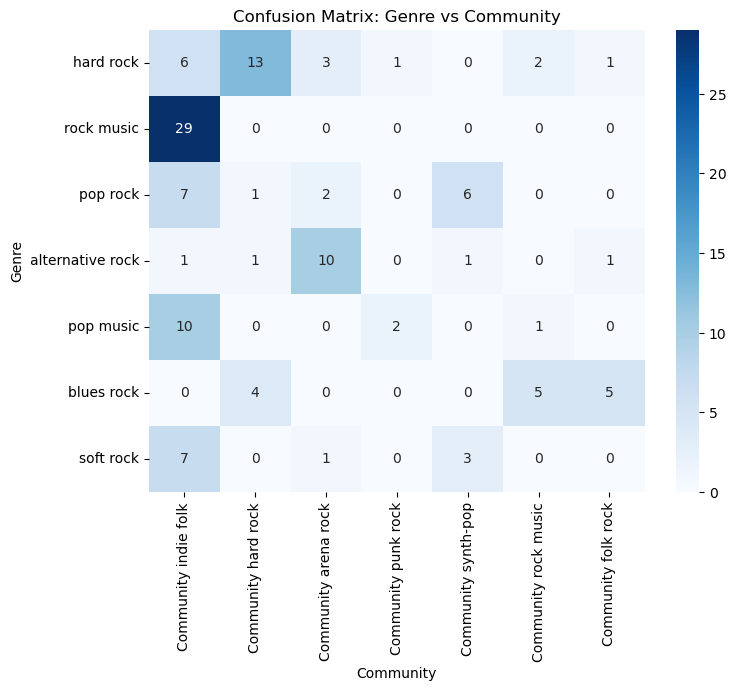

In [18]:
create_D_matrix(first_partition)

The confusion matrix shows that the communities are not accurately corresponding to the genres. This is because the first genre in the infobox usually is the broad 'rock music' genre.

I also plotted the confusion matrix for the Louvain partition.

Confusion Matrix (Genres vs Communities):
                  Community 1  Community 2  Community 3  Community 4  \
hard rock                   4            9            5            5   
rock music                  9           13            2            6   
pop rock                    6            6            5            6   
alternative rock            0            2           10            8   
pop music                  12            7            0            1   
blues rock                  1            3            9            1   
soft rock                   7            6            2            1   

                  Community 5  Community 6  Community 7  
hard rock                   6            3            0  
rock music                  0            0            0  
pop rock                    1            3            0  
alternative rock            1            1            0  
pop music                   1            1            0  
blues rock                  2    

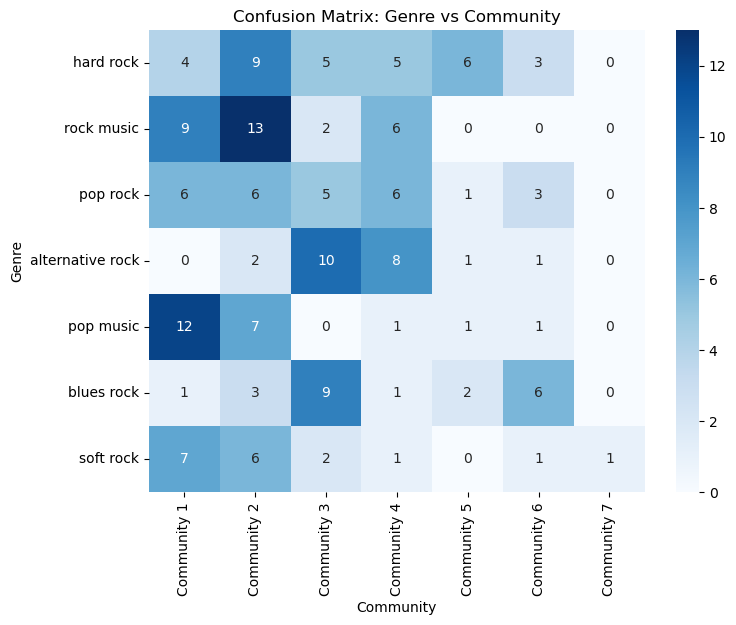

In [19]:
create_D_matrix(louvain_dict)

From the confusion matrix it can be observed that the Louvain partition distributes nodes more widely across genres, as they are not all concentrated on the 'rock music' genre as for the first genre partition.

### *Plot the communities and comment on your results.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Visualize the network, using the Force Atlas algorithm.*
* *This time assign each node a different color based on its structural community.*
* *Note: If there's a lot of small communities, it's OK to only color the 5-10 largest communities (you can make the remaing nodes light gray or some netural color)*
* *Describe the structure you observe.*

With the help of an LLM, I created a function to plot the network with the Force Atlas algorithm.

In [20]:
import matplotlib.colors as mcolors

# Create color map based on partition
def create_color_map(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.CSS4_COLORS.values())
    colors = color_map[:num_communities]

    # Map node to its community color
    node_colors = []
    node_to_color = {}
    for idx, community in enumerate(community_list):
        for node in community:
            node_to_color[node] = colors[idx]

    for node in subnetwork.nodes():
        node_colors.append(node_to_color.get(node, "#cccccc")) 
    return node_colors

# Plot graph with Force Atlas
def plot_force_atlas(partition, subnetwork):
    node_colors = create_color_map(partition, subnetwork)
    pos = nx.forceatlas2_layout(subnetwork, scaling_ratio=20, gravity=0.1)
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(subnetwork, pos=pos, node_color=node_colors, ax=ax, with_labels=False, node_size=50)
    ax.set_title("Force-Atlas layout colored by community", fontsize=16, pad=14)
    plt.show()

I plotted based on the first genre partition first.

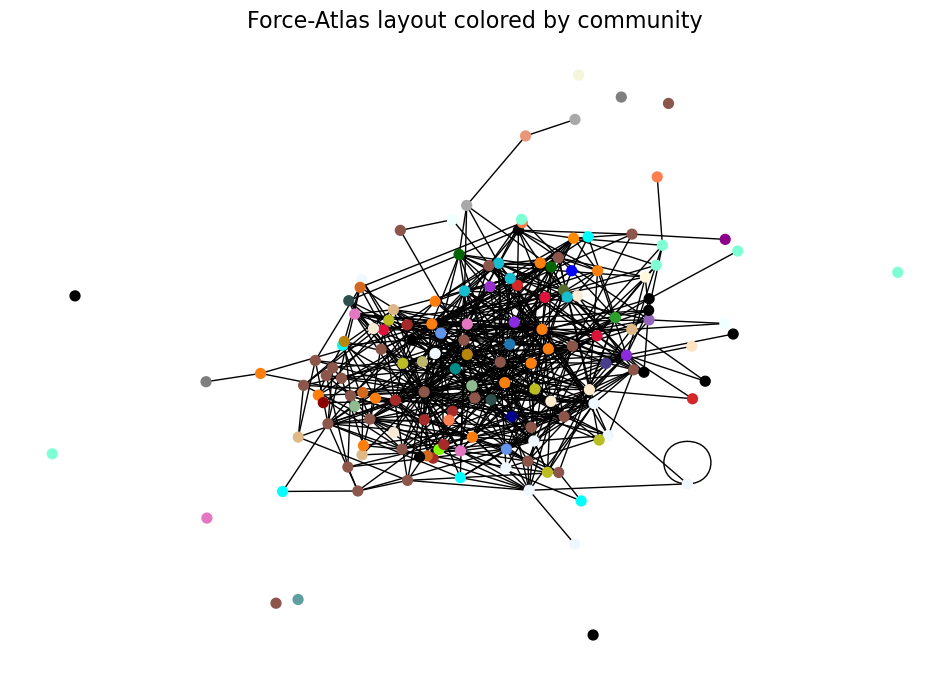

In [21]:
plot_force_atlas(first_partition, subnetwork)

Then, I plotted based on the Louvain partition.

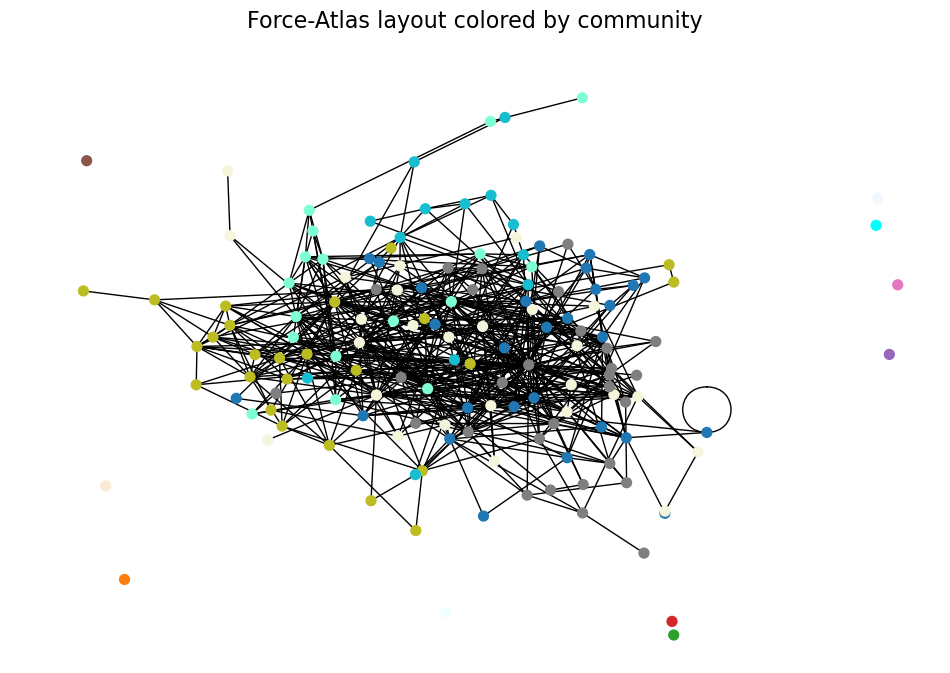

In [22]:
plot_force_atlas(louvain_dict, subnetwork)

With the help of an LLM, I tried another way to visualise the graphs, which would group the nodes in the same community closer together.

In [23]:
import numpy as np

def plot_community_aware(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)

    # Assign each community a block position
    block_positions = {}
    block_size = 10  # Spread between communities
    for idx, community in enumerate(community_list):
        # Place each block along a circle
        angle = 2 * np.pi * idx / num_communities
        block_positions[idx] = (block_size * np.cos(angle), block_size * np.sin(angle))

    # Assign initial positions for each node based on its community
    init_pos = {}
    for idx, community in enumerate(community_list):
        bx, by = block_positions[idx]
        for node in community:
            # Add small random jitter within the block
            init_pos[node] = (bx + np.random.uniform(-1, 1), by + np.random.uniform(-1, 1))

    # Create color map based on partition
    node_colors = create_color_map(partition, subnetwork)

    # Use spring_layout with these initial positions
    pos = nx.spring_layout(subnetwork, pos=init_pos, seed=42, 
                    k=2.0,  # Increased from 0.5
                    iterations=20)

    pos_scaled = {node: (x * 20, y * 20) for node, (x, y) in pos.items()}

    plt.figure(figsize=(24, 20))
    nx.draw(subnetwork, pos=pos_scaled, node_color=node_colors, 
        with_labels=False, node_size=150, edge_color="#cccccc")
    plt.title("Community-aware layout: nodes in same community are closer")
    plt.show()

I plotted the first genre partition with the spring layout.

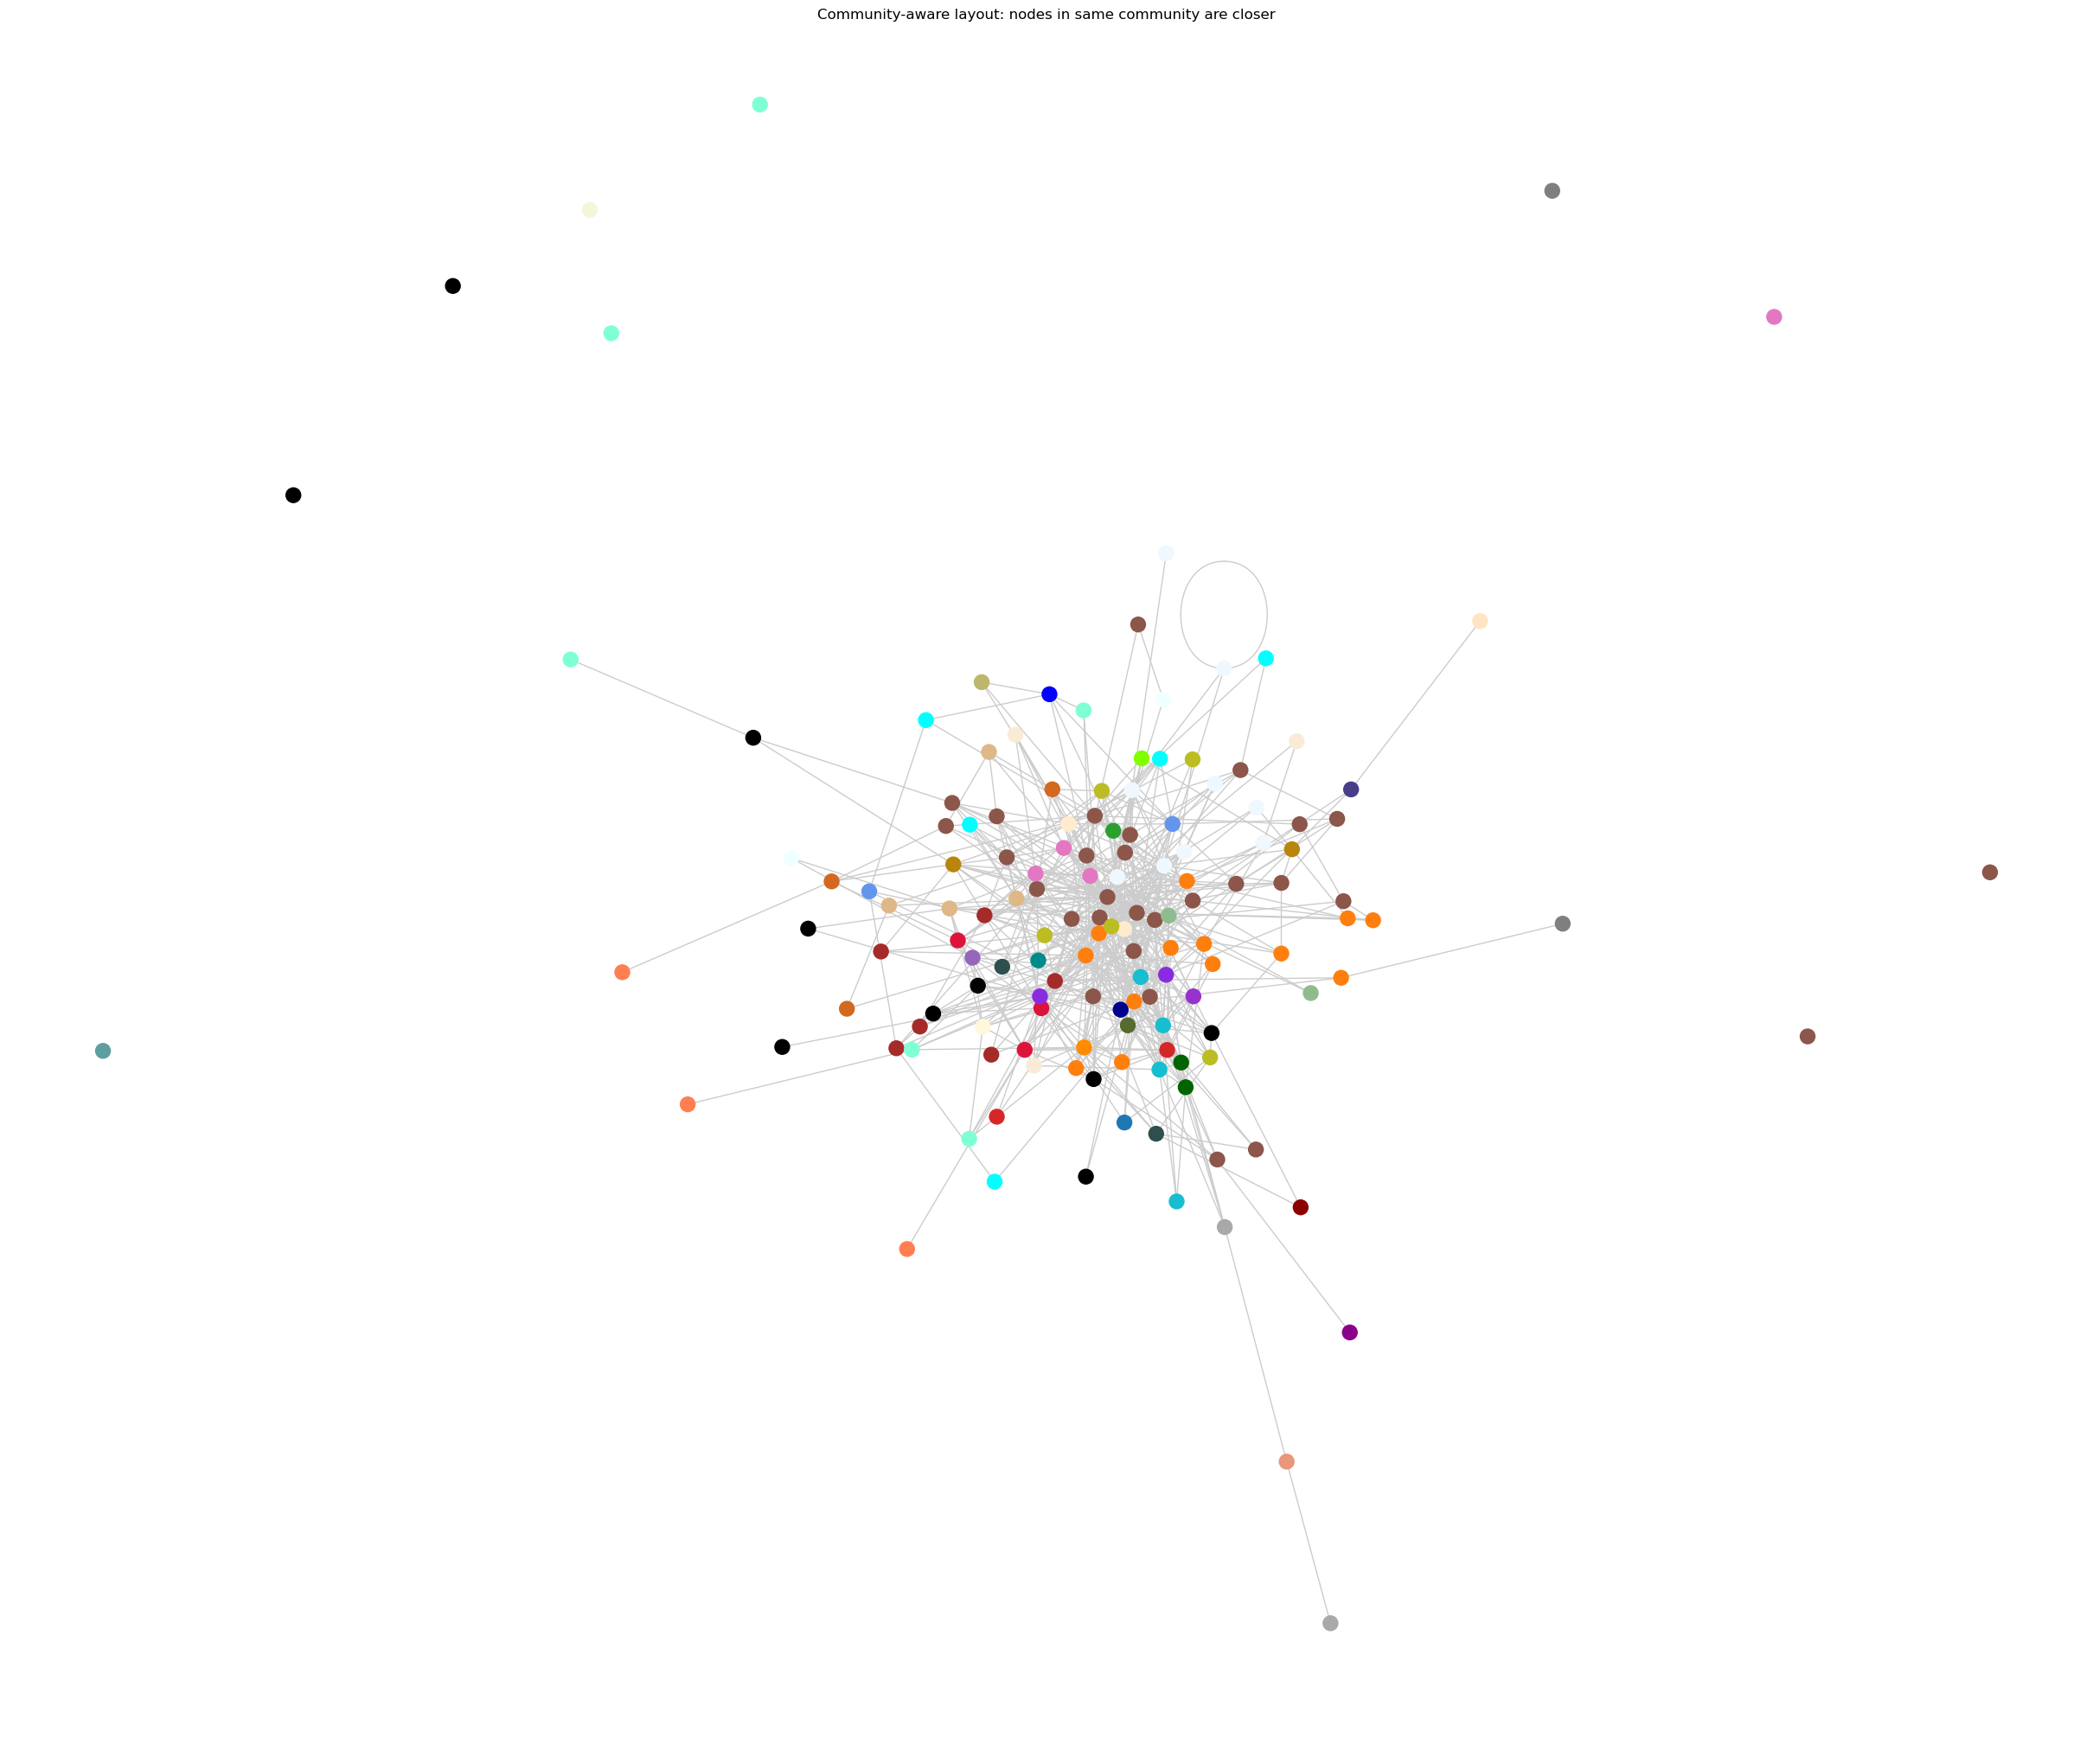

In [24]:
plot_community_aware(first_partition, subnetwork)

The updated function works better for visualising the Louvain partition, emphasizing the grouping.

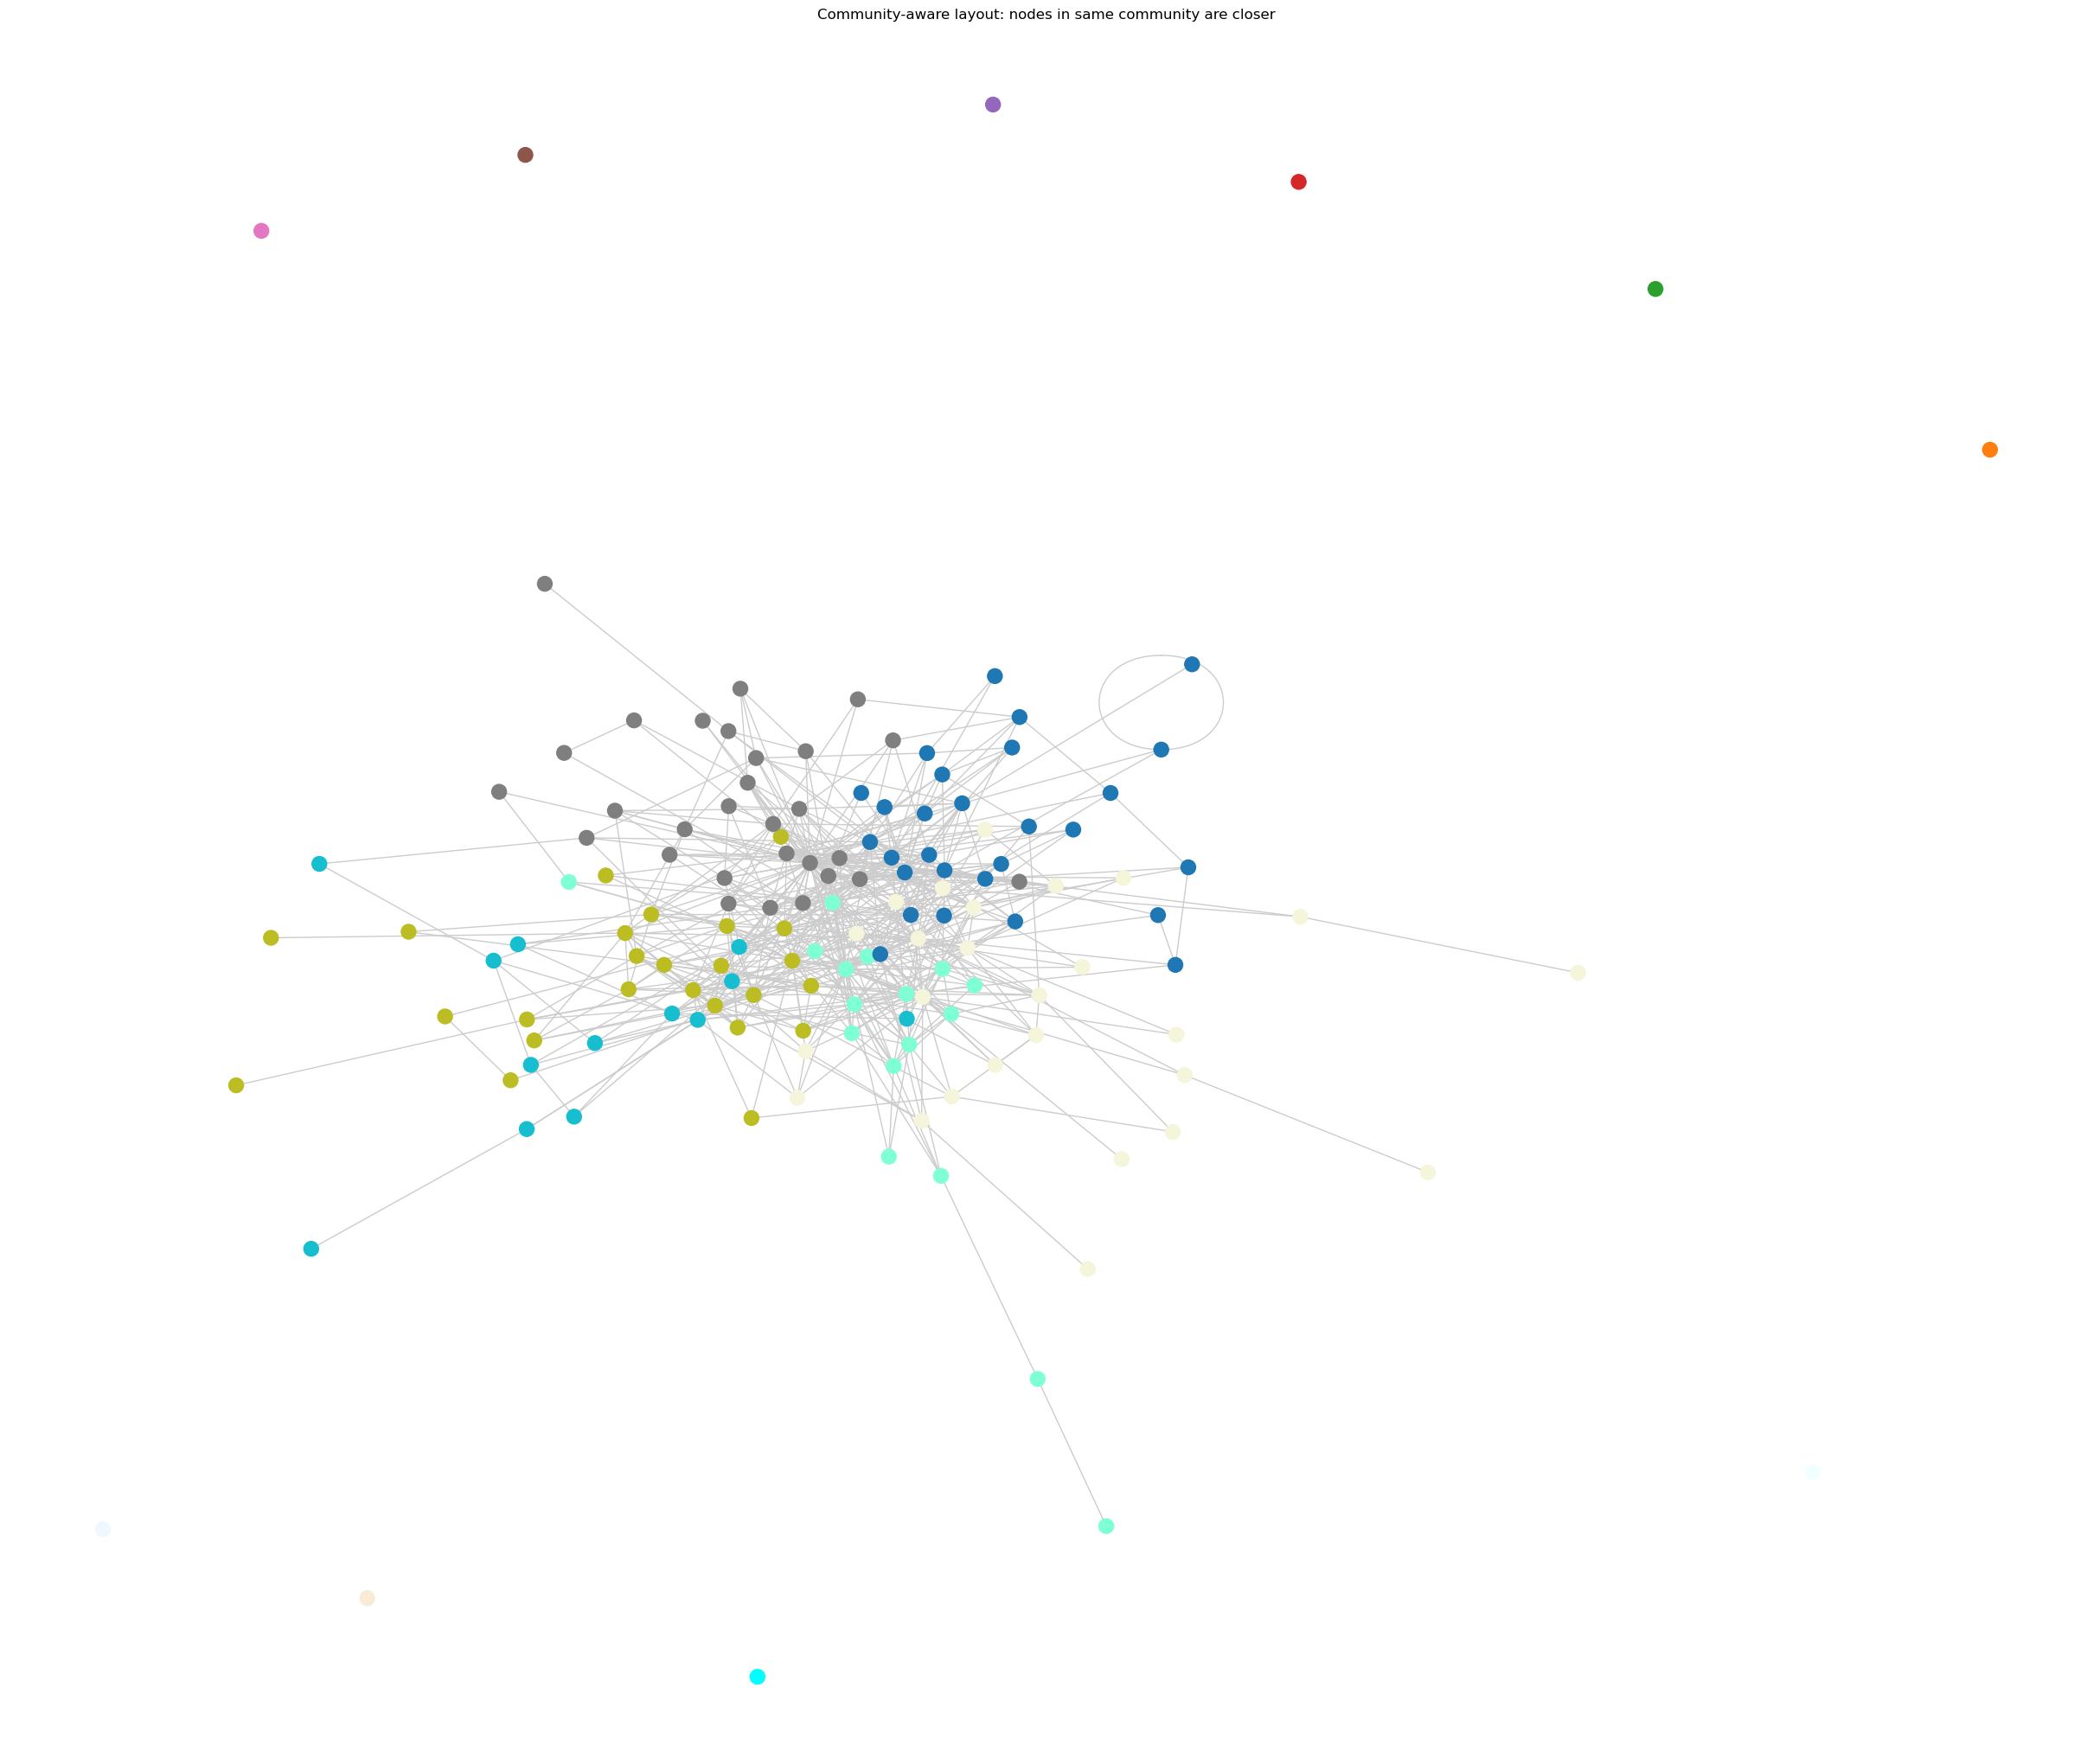

In [25]:
plot_community_aware(louvain_dict, subnetwork)

##### *Corresponding text from Week 7 exercise:* ##### 

*Keep using the community labels from above, but now visualize only the backbone-edges from your favorite network backbone from Week 5. Do the community correspond to the backbone structure you detected?*

In order to visualize the backbone-edges from the network, I download the network's backbone from Github.

In [26]:
# Load the backbone
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/backbone.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    backbone = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Backbone network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    backbone = None

✓ Backbone network loaded successfully!
  Nodes: 484
  Edges: 6301


First, I plotted the first genre partition of the backbone with the Force Atlas algorithm.

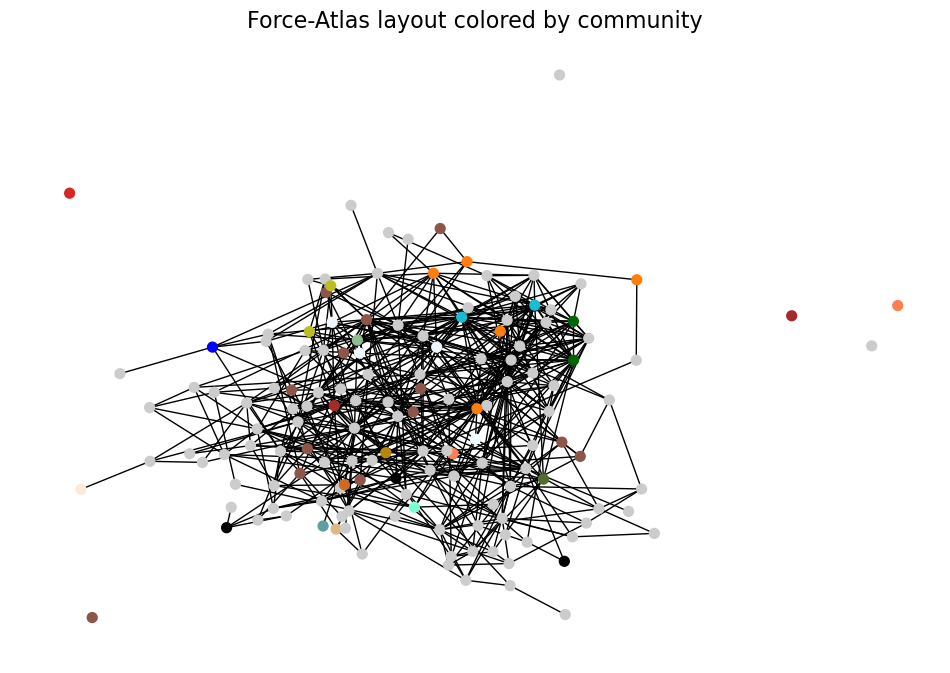

In [27]:
plot_force_atlas(first_partition, backbone)

I also plotted with my custom visualization function.

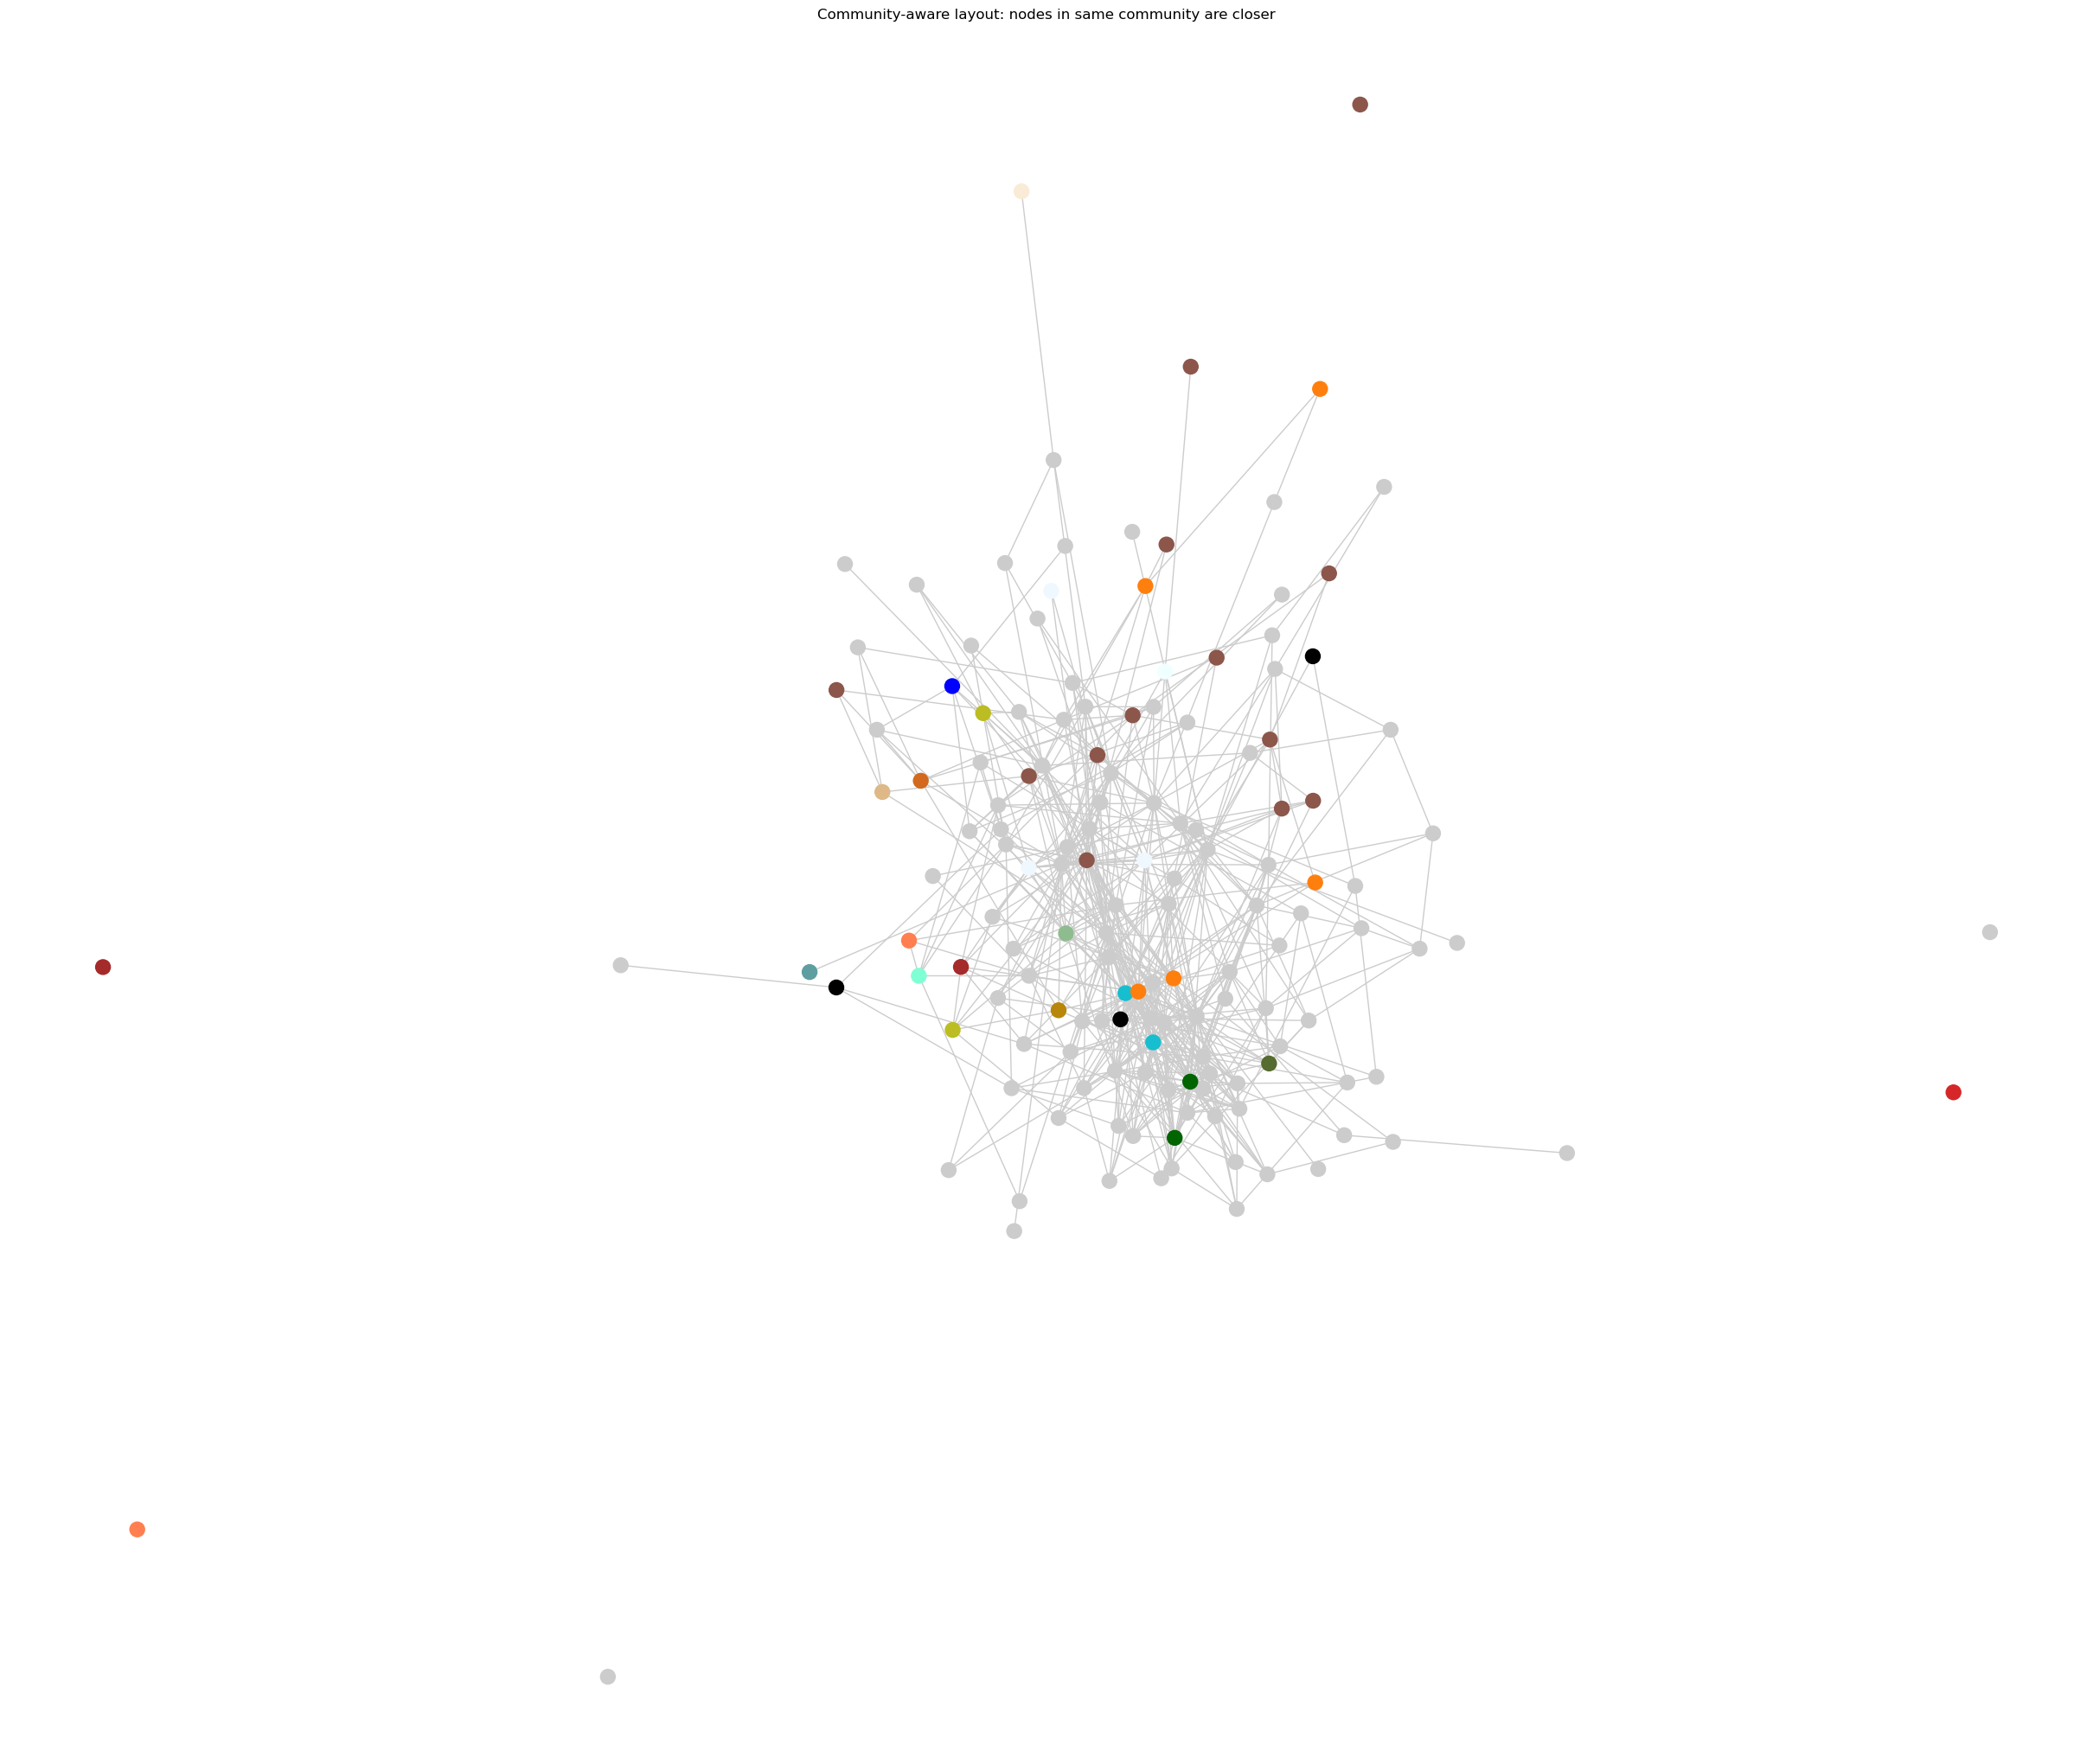

In [28]:
plot_community_aware(first_partition, backbone)

I plotted the Louvain partition of the backbone with Force Atlas.

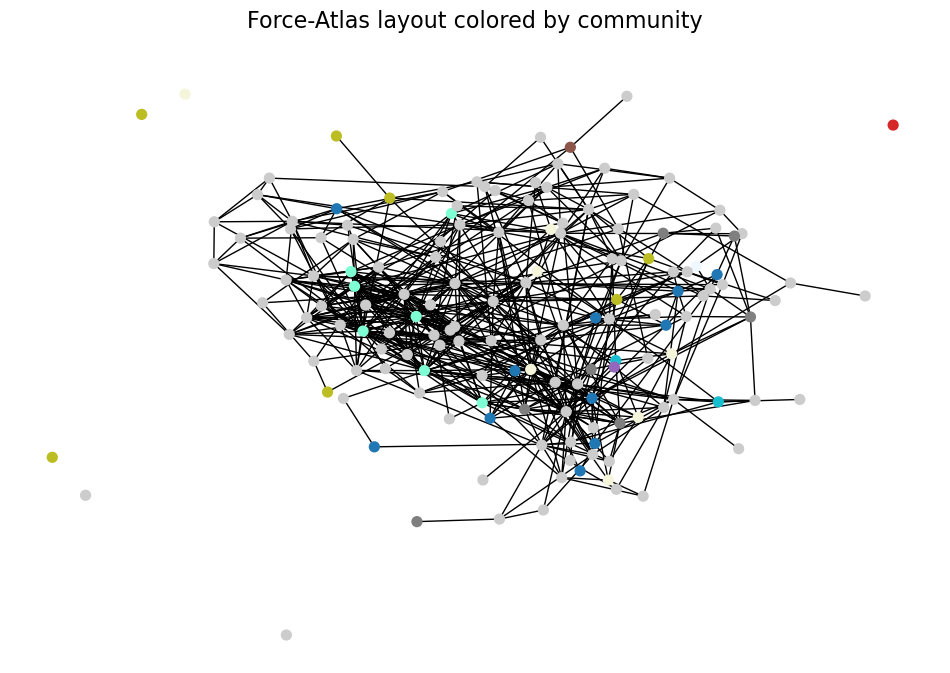

In [29]:
plot_force_atlas(louvain_dict, backbone)

Finally, I plotted with the help of my custom visualization function.

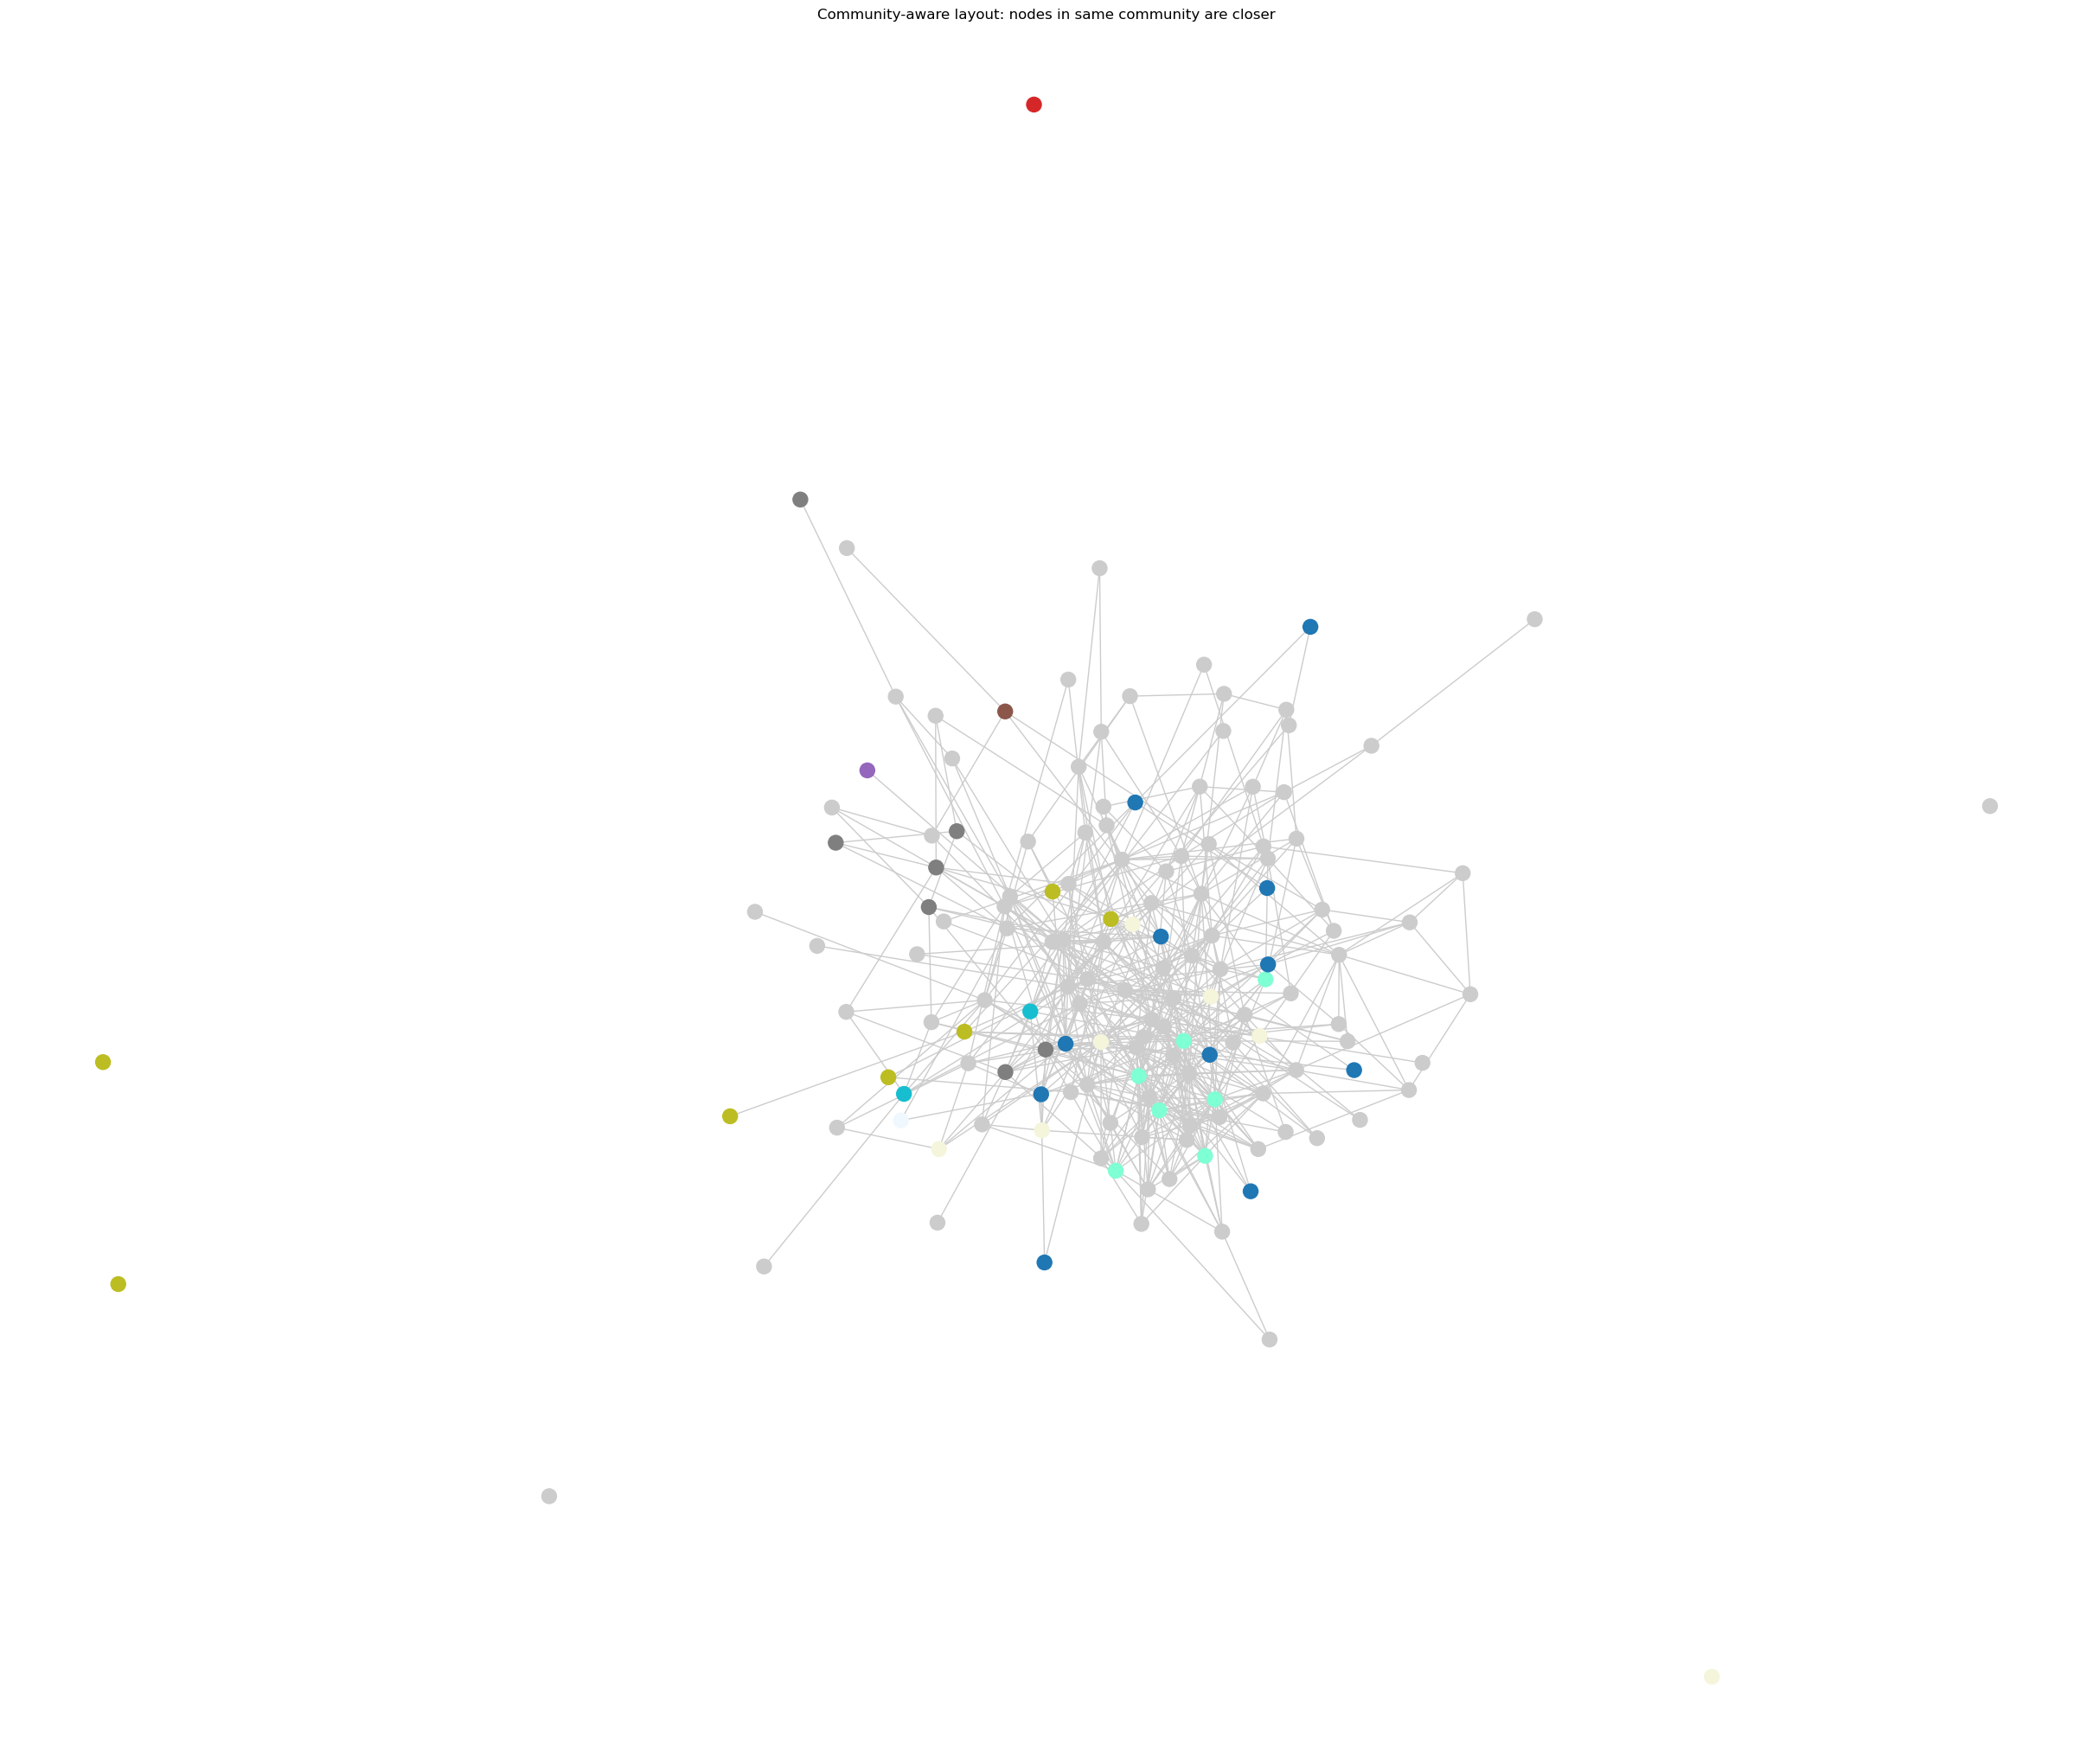

In [30]:
plot_community_aware(louvain_dict, backbone)

# **Part 3: TF-IDF to understand genres and communities**

### **Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.**

Note: All the formulas provided are referenced from https://en.wikipedia.org/wiki/Tf%E2%80%93idf

TF-IDF (Term Frequency - Inverse Document Frequency) is a numerical scoring system that combines TF and IDF to evaluate the importance of word in a document. In order to understand TF-IDF, we need to understand what TF and IDF are.

TF, short for Term Frequency, measures how frequent a word appears in a document. The more a word appears, the higher TF score is going to be and the more important it might be to that document. The simplest way to calculate TF is to count the number of times a word appears in a document. Besides that, there are several other ways to determine the value of TF. Here are some of the available weighting schemes:

Binary: $0, 1$

Term frequency: $\frac{f_{w,d}}{\sum_{w'\in d}{f_{w',d}}}$

Log normalization: $\log(1 + f_{w,d})$

Double normalization: $0.5 + 0.5 \cdot \frac{f_{w,d}}{\max_{w' \in d}f_{w',d}}$

Double normalization $K$: $K + (1 - K) \frac{f_{w,d}}{\max_{w' \in d} f_{w',d}}$

Where $f_{w,d}$ represent the raw count of word $w$ in document $d$.

IDF, short for Inverse Document Frequency, measures how rare a word is across all documents. The less number of documents that contain a word, the higher the IDF score is going to be and the rarer or characteristic it is to those documents. It is calculated by taking the logarithm of inverse fraction of the documents that contain the word ( $\log\frac{N}{n_w} = -\log\frac{n_w}{N}$ ). In addition, there also some other types of IDF. Here are some of the other weighting schemes:

Unary (just TF): $1$

Inverse document frequency smooth: $\log \left( \frac{N}{1 + n_w} \right) + 1$

Inverse document frequency max: $\log \left( \frac{\max_{w' \in d} n_{w'}}{1 + n_t} \right)$

Probabilistic inverse document frequency: $\log \frac{N - n_w}{n_w}$

Where $N$ is total number of documents and $n_t$ is the number of documents that contains the word

TF-IDF is calculated by taking the product of TF and IDF scores of a word, $TD-IDF(w,d) = TF(w,d)\cdot IDF(w)$. This method highlights words in a document that have not only high frequency but also rare in other documents. Although words like stopwords or generic nouns (such as album, song, release) have a high TF, it is penalized by existing in most documents causing a low IDF scores. Words with high TF-IDF are a good characteristics of a document as it is frequently seen in that document but still uncommon in other documents.

In understanding genres and communities, TF-IDF is really helpful in identifying words that are characteristics to a specific group (genres or communities). Words that have high TF-IDF scores shows what vocabulary uniquely identifies that specific group. Only words that has a balance of being frequently seen within the group and unique enough across grorups will receive a high TF-IDF score, proving that they are unique characteristics of that group.

In [31]:
# Prepare the top n genres and communities
n = len(louvain_dict) if len(louvain_dict) < 7 else 7

sorted_community_sizes = sorted([(len(members), comm_id) for comm_id, members in louvain_dict.items()])[::-1]
top_communities = [comm_id for count, comm_id in sorted_community_sizes][:n]


top_genres = [genre for genre, count in stats['top_15_genres'][:n]]

In [32]:
# Just a helper function to get the pages content
def load_content(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return ""
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    return wikitext

In [33]:
genre_docs = {}
for nodes in subnetwork.nodes():
    genres = subnetwork.nodes[nodes]['genres']
    content = load_content(subnetwork.nodes[nodes]['content'])
    for genre in genres:
        if genre in top_genres:
            if genre not in genre_docs:
                genre_docs[genre] = []
            genre_docs[genre].append(content)
for genre, docs in genre_docs.items():
    genre_docs[genre] = ' '.join(docs)
    print(f"Genre: {genre}, Number of documents: {len(docs)}, Length of combined text: {len(genre_docs[genre]):,} characters")
print(f"\n{len(genre_docs)} genre documents prepared\n")

Genre: hard rock, Number of documents: 33, Length of combined text: 2,631,061 characters
Genre: pop rock, Number of documents: 29, Length of combined text: 1,921,320 characters
Genre: blues rock, Number of documents: 22, Length of combined text: 1,533,776 characters
Genre: alternative rock, Number of documents: 24, Length of combined text: 2,228,200 characters
Genre: rock music, Number of documents: 32, Length of combined text: 2,995,219 characters
Genre: soft rock, Number of documents: 20, Length of combined text: 1,357,182 characters
Genre: pop music, Number of documents: 22, Length of combined text: 1,886,234 characters

7 genre documents prepared



In [34]:
community_docs = {}
for comm_id in top_communities:
    members = louvain_dict[comm_id]
    for node in members:
        content = load_content(subnetwork.nodes[node]['content'])
        if comm_id not in community_docs:
            community_docs[comm_id] = []
        community_docs[comm_id].append(content)
for comm_id, docs in community_docs.items():
    community_docs[comm_id] = ' '.join(docs)
    print(f"Community ID: {comm_id}, Number of documents: {len(docs)}, Length of combined text: {len(community_docs[comm_id]):,} characters")
print(f"\n{len(community_docs)} community documents prepared\n")

Community ID: 8, Number of documents: 29, Length of combined text: 2,063,183 characters
Community ID: 1, Number of documents: 28, Length of combined text: 2,300,305 characters
Community ID: 16, Number of documents: 26, Length of combined text: 1,975,529 characters
Community ID: 9, Number of documents: 25, Length of combined text: 2,302,676 characters
Community ID: 14, Number of documents: 17, Length of combined text: 2,041,696 characters
Community ID: 10, Number of documents: 13, Length of combined text: 668,078 characters
Community ID: 15, Number of documents: 1, Length of combined text: 38,533 characters

7 community documents prepared



##### **Corresponding text from Week 7 Part 2 exercises:** #####

**Action items**

* **Tokenize the pages into one long string per genre**

* **Remove all punctuation from your list of tokens**

* **Set everything to lower case**

* **(Optional) Lemmatize your words**

* **It’s a good idea to filter out rare words (e.g. words that only appear less than 5 times).**

In [35]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kyleelyk/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [36]:
def clean_and_tokenize(text):
    # Remove URLs and web-specific content
    text = re.sub(r'https?://\S+', '', text)  # Remove http/https URLs
    text = re.sub(r'www\.\S+', '', text)  # Remove www. domains
    text = re.sub(r'\S+\.(com|org|net|edu|gov|uk)\b', '', text, flags=re.IGNORECASE)
    
    # Remove Wikipedia/HTML markup
    text = re.sub(r'\{\{[^}]+\}\}', '', text)  # Remove {{template}}
    text = re.sub(r'\[\[[^\]]+\]\]', '', text)  # Remove [[links]]
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)  # Remove <ref> tags
    text = re.sub(r'<[^>]+>', '', text)  # Remove all HTML tags
    text = re.sub(r'\[\[(Category|File|Image):[^\]]+\]\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bstyle\s*=\s*["\'][^"\']*["\']', '', text)  # Remove style attributes
    text = re.sub(r'\b(align|valign|colspan|rowspan|width|height)\b\s*=\s*\S+', '', text)
    
    # Set everything to lowercase
    text = text.lower()
    
    # Remove all punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize (split by whitespace)
    tokens = text.split()
    
    # Filter, remove stop words, and lemmatize
    cleaned_tokens = []
    for token in tokens:
        # Skip stop words
        if token in stop_words:
            continue
        
        # Skip if not alphabetic
        if not token.isalpha():
            continue
        
        # Skip very short words
        if len(token) < 3:
            continue
        
        # Skip very long words
        if len(token) > 20:
            continue
        
        # Lemmatize to reduce inflectional forms to base form
        lemmatized = lemmatizer.lemmatize(token)

        # Add to cleaned tokens
        cleaned_tokens.append(lemmatized)
    
    return cleaned_tokens

### **Calculate and visualize TF-IDF for the genres and communities.**

##### **Corresponding text from Week 7 Part 6 exercise:** #####

* **We’re now ready to calculate TF-IDFs. Do that for each genre.**

In [37]:
def compute_tf_idf(documents_dict, min_df=2):
    # Tokenize and compute term frequencies
    doc_term_freq = {}
    doc_total_terms = {}

    for doc_id, text in documents_dict.items():
        tokens = clean_and_tokenize(text)
        term_counts = Counter(tokens)
        doc_term_freq[doc_id] = term_counts
        doc_total_terms[doc_id] = len(tokens)
        print(f"Document '{doc_id}': {len(tokens):,} tokens, {len(term_counts):,} unique terms")
    
    # Compute document frequency for each term
    term_doc_freq = Counter()
    all_terms = set()
    
    for doc_id, term_counts in doc_term_freq.items():
        for term in term_counts.keys():
            term_doc_freq[term] += 1
            all_terms.add(term)

    # Filter by document frequency: keep terms appearing in at least min_df documents
    N = len(documents_dict)
    filtered_terms = {term for term, df in term_doc_freq.items() if df >= min_df}
    
    # Calculate IDF only for filtered terms
    idf_scores = {}
    for term in filtered_terms:
        doc_freq = term_doc_freq[term]
        # Using standard IDF: log(N/df)
        idf = np.log(N / doc_freq)
        idf_scores[term] = idf

    # Compute TF-IDF for each document
    tf_idf_matrix = {}
    for doc_id, term_counts in doc_term_freq.items():
        tf_idf_vector = {}
        total_terms = doc_total_terms[doc_id]
        
        # Skip empty documents to avoid division by zero
        if total_terms == 0:
            tf_idf_matrix[doc_id] = {}
            continue

        for term, count in term_counts.items():
            # Using normalized TF: term_count / total_terms
            tf = count / total_terms
            if term in idf_scores:
                tf_idf = tf * idf_scores[term]
                if tf_idf > 0:
                    tf_idf_vector[term] = tf_idf

        tf_idf_matrix[doc_id] = tf_idf_vector
    return tf_idf_matrix, idf_scores

In [65]:
genre_tf_idf, genre_idf = compute_tf_idf(genre_docs, min_df=1)

Document 'hard rock': 60,583 tokens, 8,766 unique terms
Document 'pop rock': 41,303 tokens, 6,641 unique terms
Document 'blues rock': 33,691 tokens, 6,310 unique terms
Document 'alternative rock': 49,437 tokens, 7,639 unique terms
Document 'rock music': 70,601 tokens, 9,939 unique terms
Document 'soft rock': 28,086 tokens, 5,025 unique terms
Document 'pop music': 49,928 tokens, 7,937 unique terms


##### **Corresponding text from Week 7 Part 6 exercise:** #####

* **Redo the exercise above but for the structural communities. You probably have fewer than 15, that’s fine. Just do the analysis for the ones you have.**

In [39]:
community_tf_idf, community_idf = compute_tf_idf(community_docs, min_df=1)

Document '8': 51,165 tokens, 8,038 unique terms
Document '1': 49,341 tokens, 7,909 unique terms
Document '16': 46,630 tokens, 7,622 unique terms
Document '9': 53,678 tokens, 8,549 unique terms
Document '14': 49,436 tokens, 7,355 unique terms
Document '10': 16,599 tokens, 3,924 unique terms
Document '15': 1,468 tokens, 556 unique terms


##### **Corresponding text from Week 7 Part 6 exercise:** #####

* **Which base logarithm did you use? Is that important?.**

I used natural logarithm to calculate TF-IDF. Observing the IDF formula:

$\log_b \frac{N}{n_t} = \frac{\log_k \frac{N}{n_t}}{\log_k b}$

Changing the base will just multiplies all IDF scores by $\frac{1}{\log_k b}$. Meaning that the ranking of the words will stay the same no matter which base logarithm used. What is important to identify from TF-IDF is the rankings of the words not the value of the scores itself. So, no it is not important which base logarithm is used.

In [40]:
def visualize_tfidf_terms(tf_idf_dict, labels, title, top_n=15, label_formatter=None):
    # Create visualization
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()
    
    for idx, label in enumerate(labels):
        ax = axes[idx]
        
        # Format label for display
        display_label = label_formatter(label) if label_formatter else str(label)
        
        if label not in tf_idf_dict or not tf_idf_dict[label]:
            ax.text(0.5, 0.5, f'No data\nfor\n{display_label}',
                    ha='center', va='center', fontsize=12, color='gray')
            ax.set_title(display_label, fontsize=11, fontweight='bold')
            ax.axis('off')
            continue
        
        # Get top N terms
        top_terms = sorted(tf_idf_dict[label].items(), key=lambda x: x[1], reverse=True)[:top_n]
        terms, scores = zip(*top_terms)
        
        # Plot
        y_pos = range(len(terms))
        ax.barh(y_pos, scores, color='steelblue')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(terms, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('TF-IDF Score', fontsize=10)
        ax.set_title(display_label, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(labels), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

##### **Corresponding text from Week 7 Part 6 exercise:** #####

* **List the 10 top words for each genre accourding to TF-IDF. Are these 10 words more descriptive of the genre than just the TF? Justify your answer.**

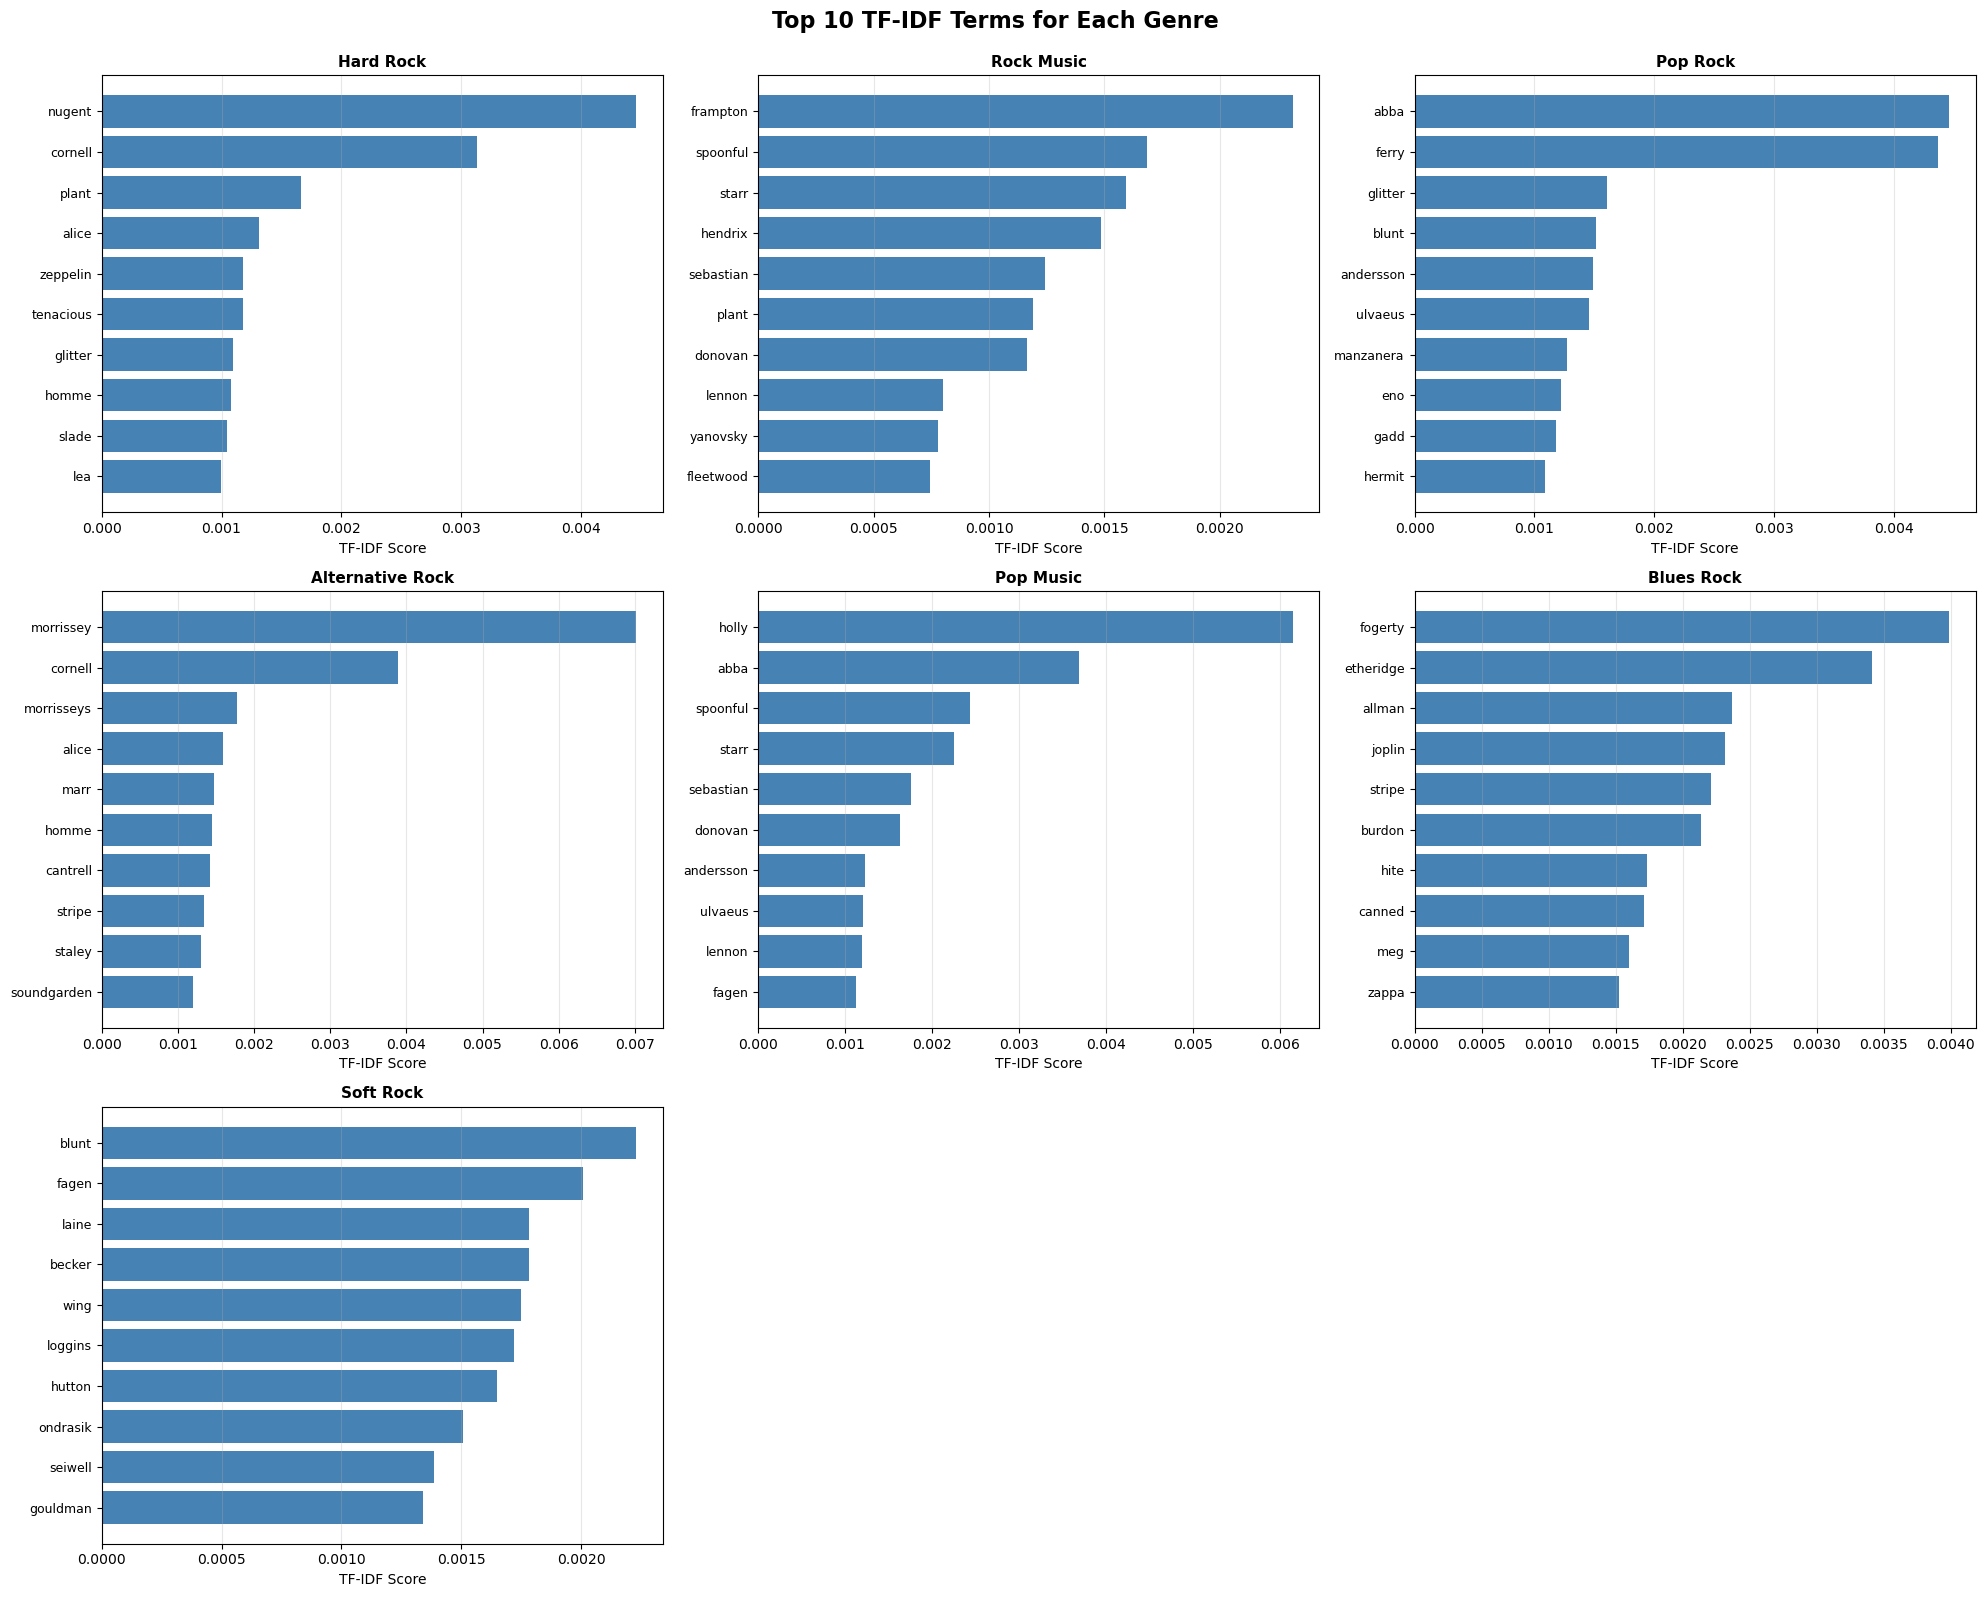

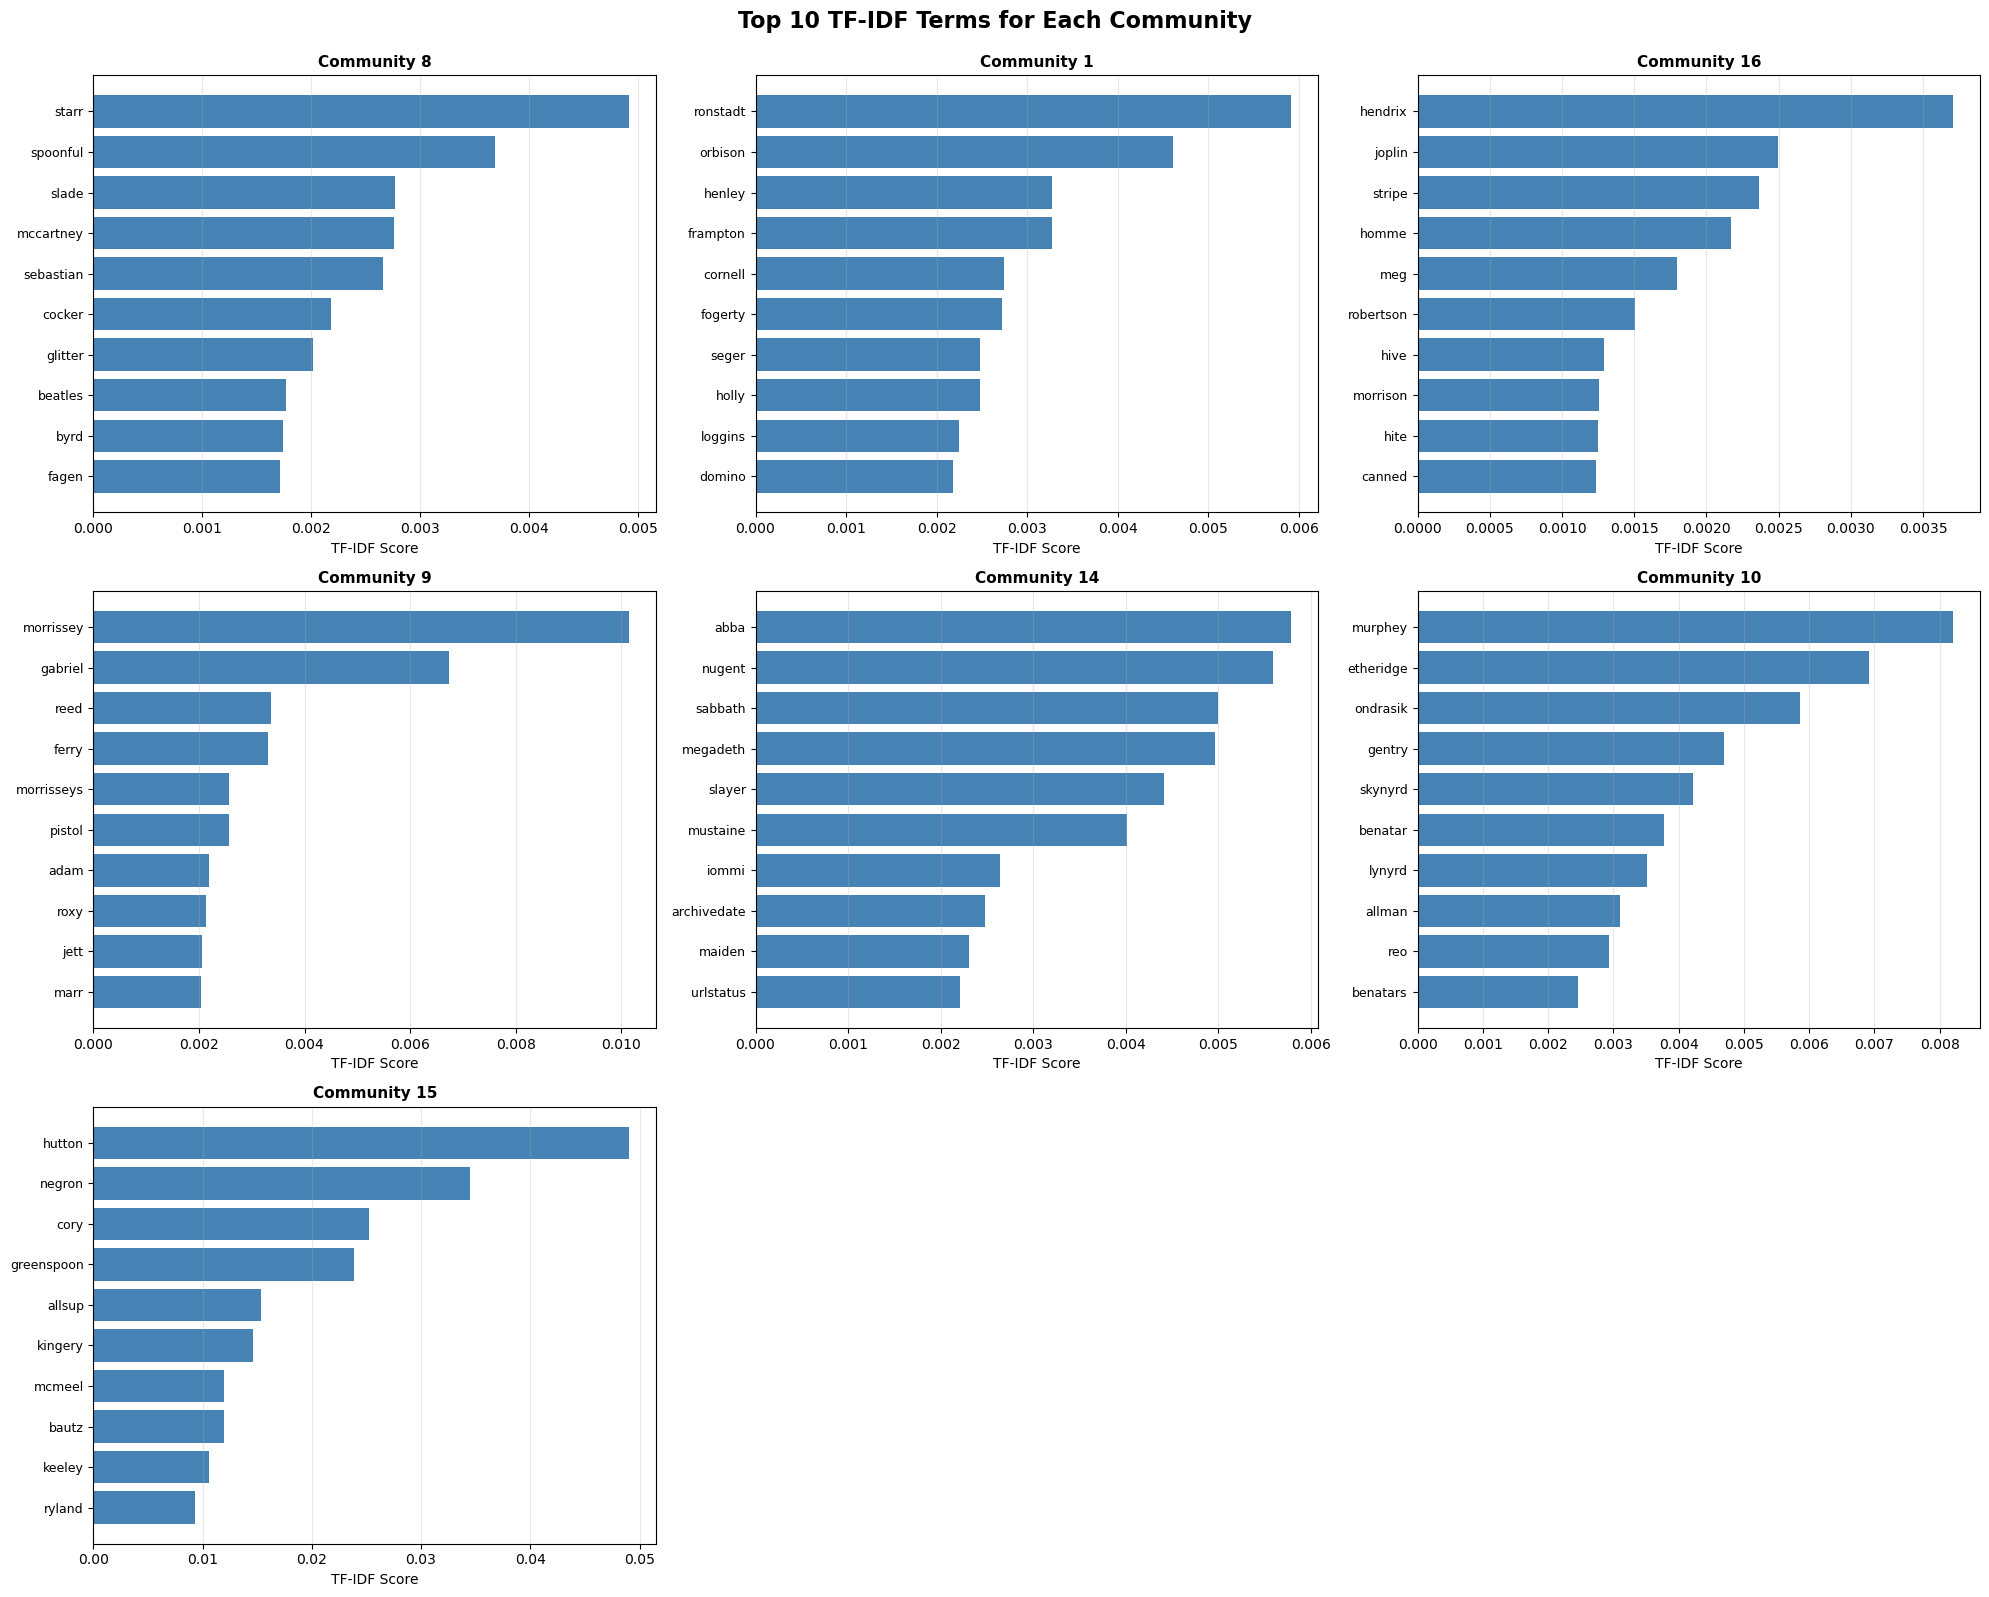

In [ ]:
# Visualize genres
visualize_tfidf_terms(
    genre_tf_idf,
    top_genres,
    'Top 10 TF-IDF Terms for Each Genre',
    top_n=10,
    label_formatter=lambda x: x.title()
)

# Visualize communities
visualize_tfidf_terms(
    community_tf_idf,
    top_communities,
    'Top 10 TF-IDF Terms for Each Community',
    top_n=10,
    label_formatter=lambda x: f'Community {x}'
)

If we are just using TF, assuming we still clean the tokens beforehand, general music related words such as *album, music, song, release, band* will dominate the top TF ranking. Maybe some popular rock artist would show up in the top TF ranking here and there will overall won't be a good description of each genre.

Whereas in these Figures above, we can clearly see a lot of artist names in each of the top TF-IDF ranking. 

##### **Corresponding text from Week 7 Part 6 exercise:** #####

* **Create a wordcloud for each genre.**

In [42]:
def create_tfidf_wordclouds(tfidf_dict, labels, title, colormap_base='viridis'):
    from wordcloud import WordCloud
    
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    axes = axes.flatten()
    
    # Different colormaps for variety
    colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'Blues', 'Reds']
    
    for idx, label in enumerate(labels):
        ax = axes[idx]
        
        if label not in tfidf_dict or not tfidf_dict[label]:
            # Handle missing data
            display_label = label.title() if isinstance(label, str) else f'Community {label}'
            ax.text(0.5, 0.5, f'No data\nfor\n{display_label}',
                    ha='center', va='center', fontsize=14, color='gray')
            ax.set_title(display_label, fontsize=12, fontweight='bold', pad=10)
            ax.axis('off')
            continue
        
        # Generate word cloud from TF-IDF scores
        wc = WordCloud(width=800, height=600,
                        background_color='white',
                        colormap=colormaps[idx % len(colormaps)],
                        max_words=100,
                        relative_scaling=0.5,
                        min_font_size=8).generate_from_frequencies(tfidf_dict[label])
        
        # Display
        ax.imshow(wc, interpolation='bilinear')
        
        # Format title based on label type
        if isinstance(label, str):
            display_label = label.title()
        else:
            display_label = f'Community {label}'
        
        ax.set_title(display_label, fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(len(labels), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

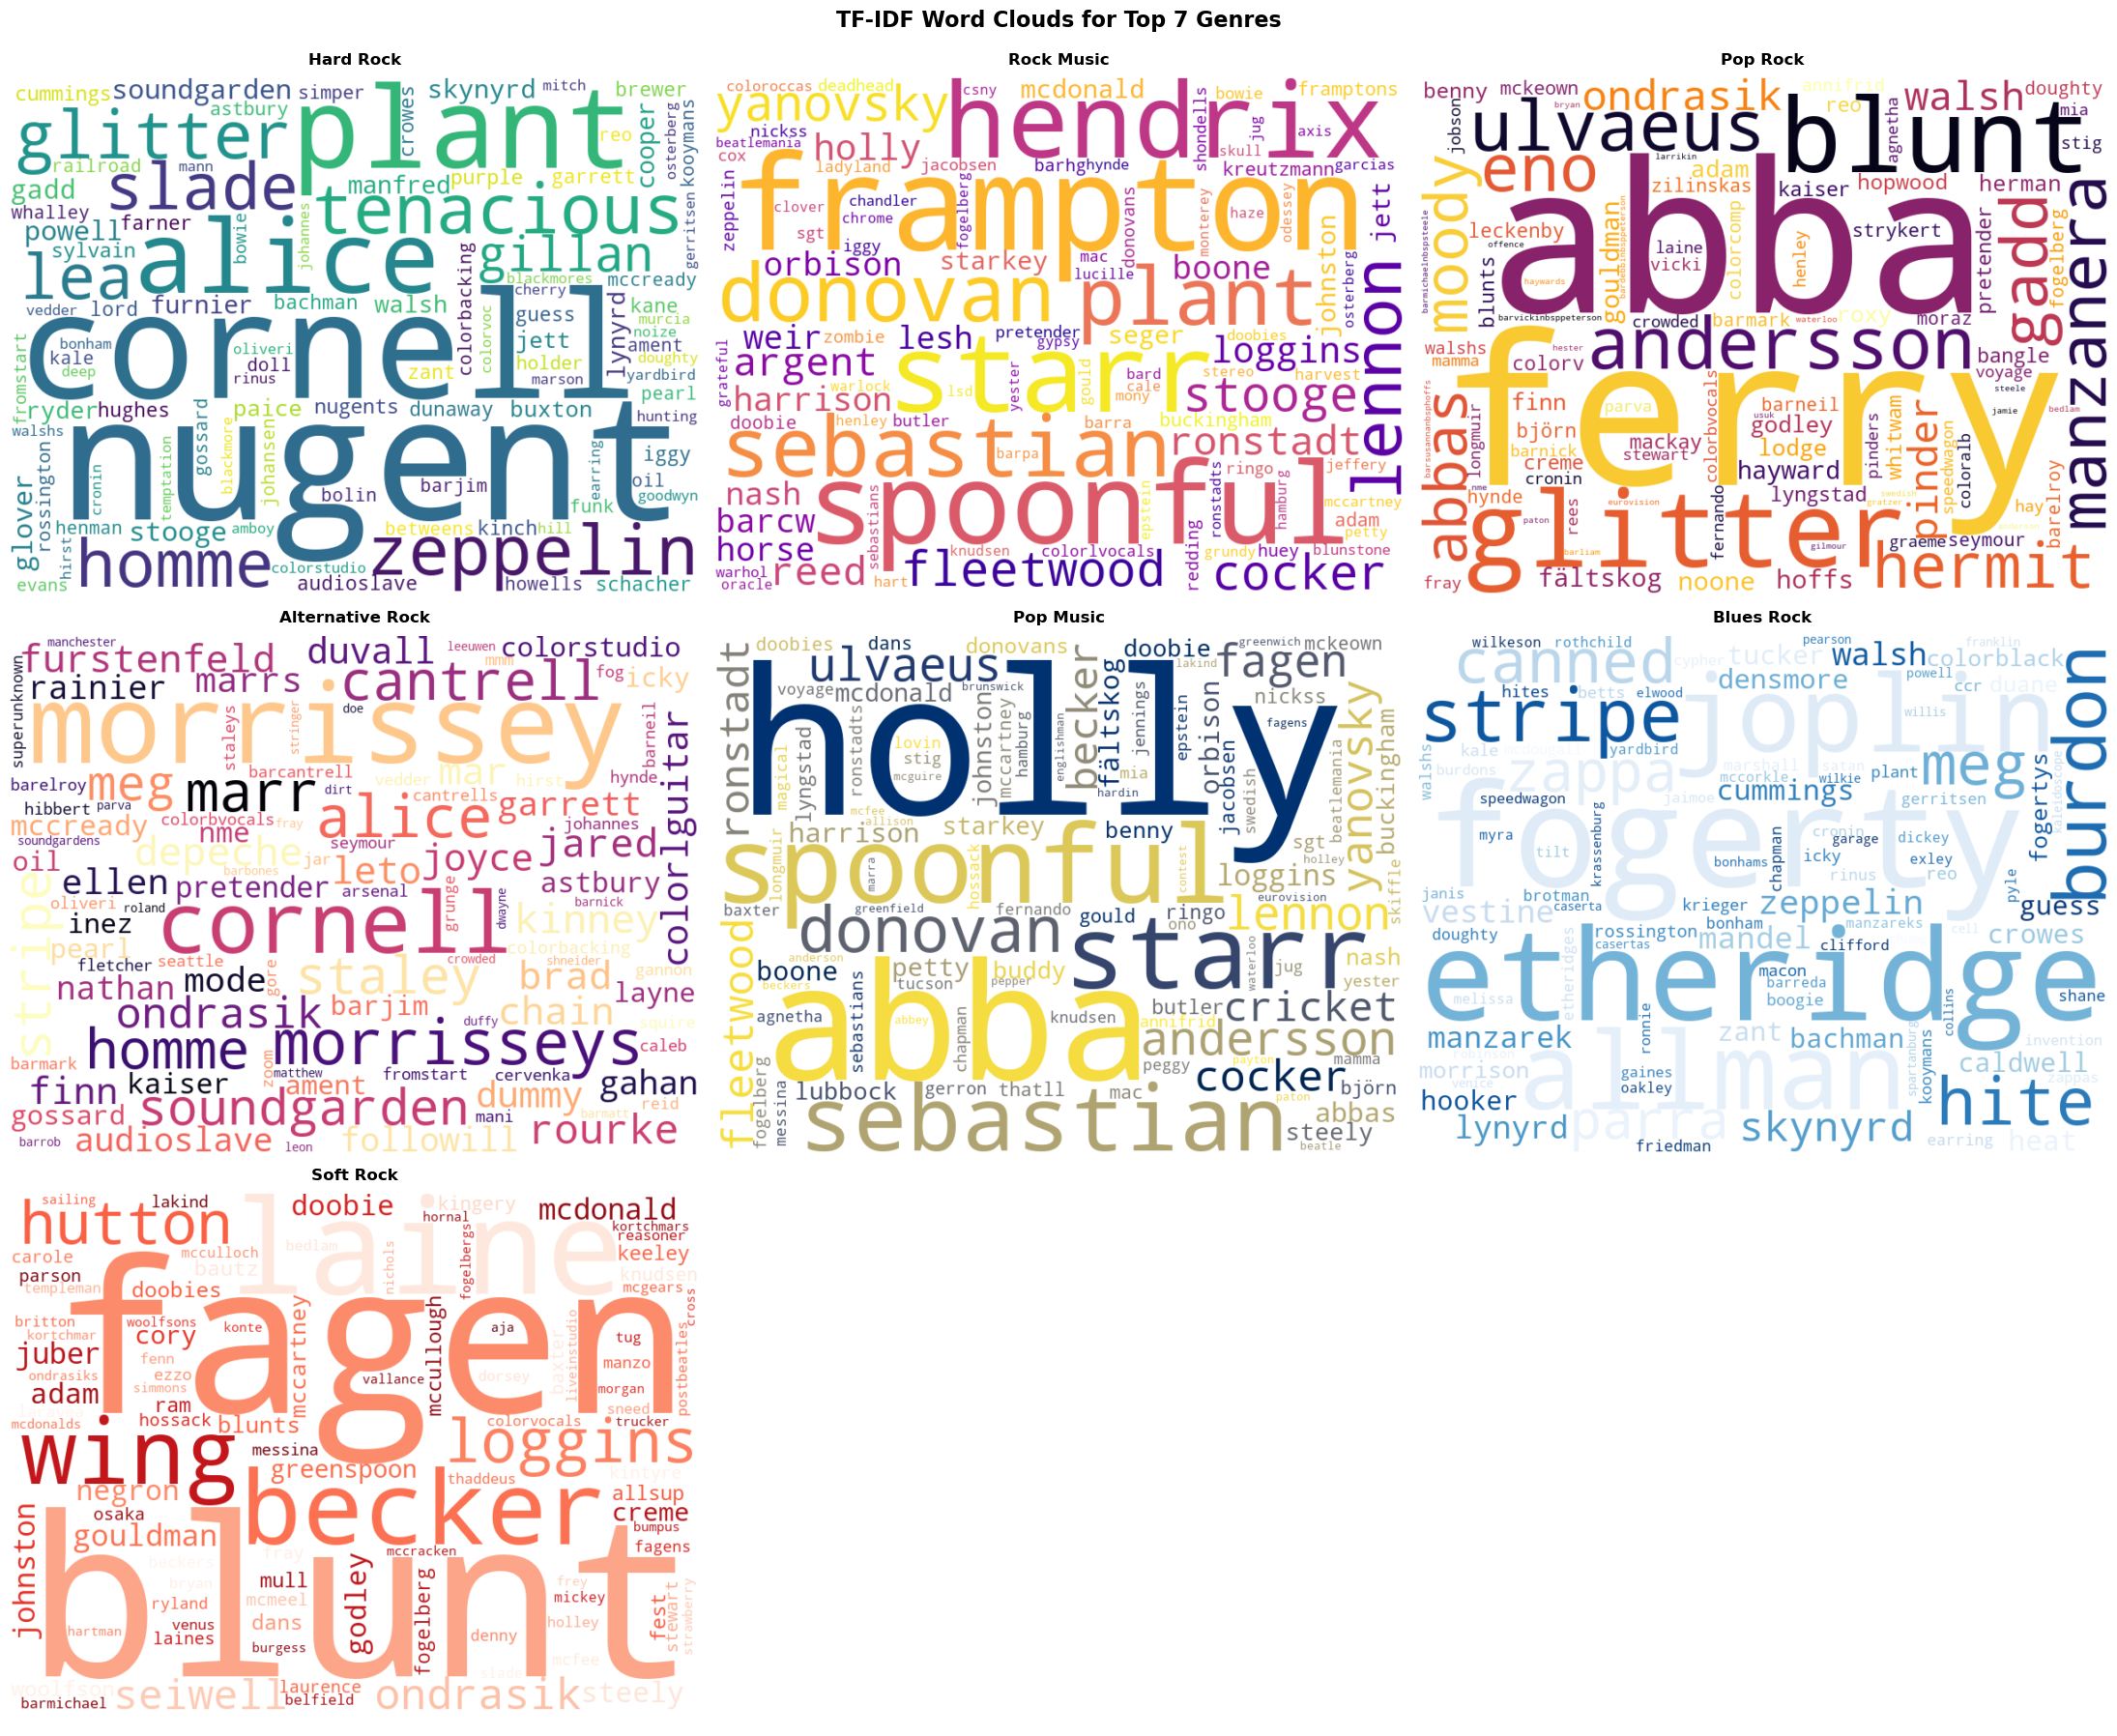

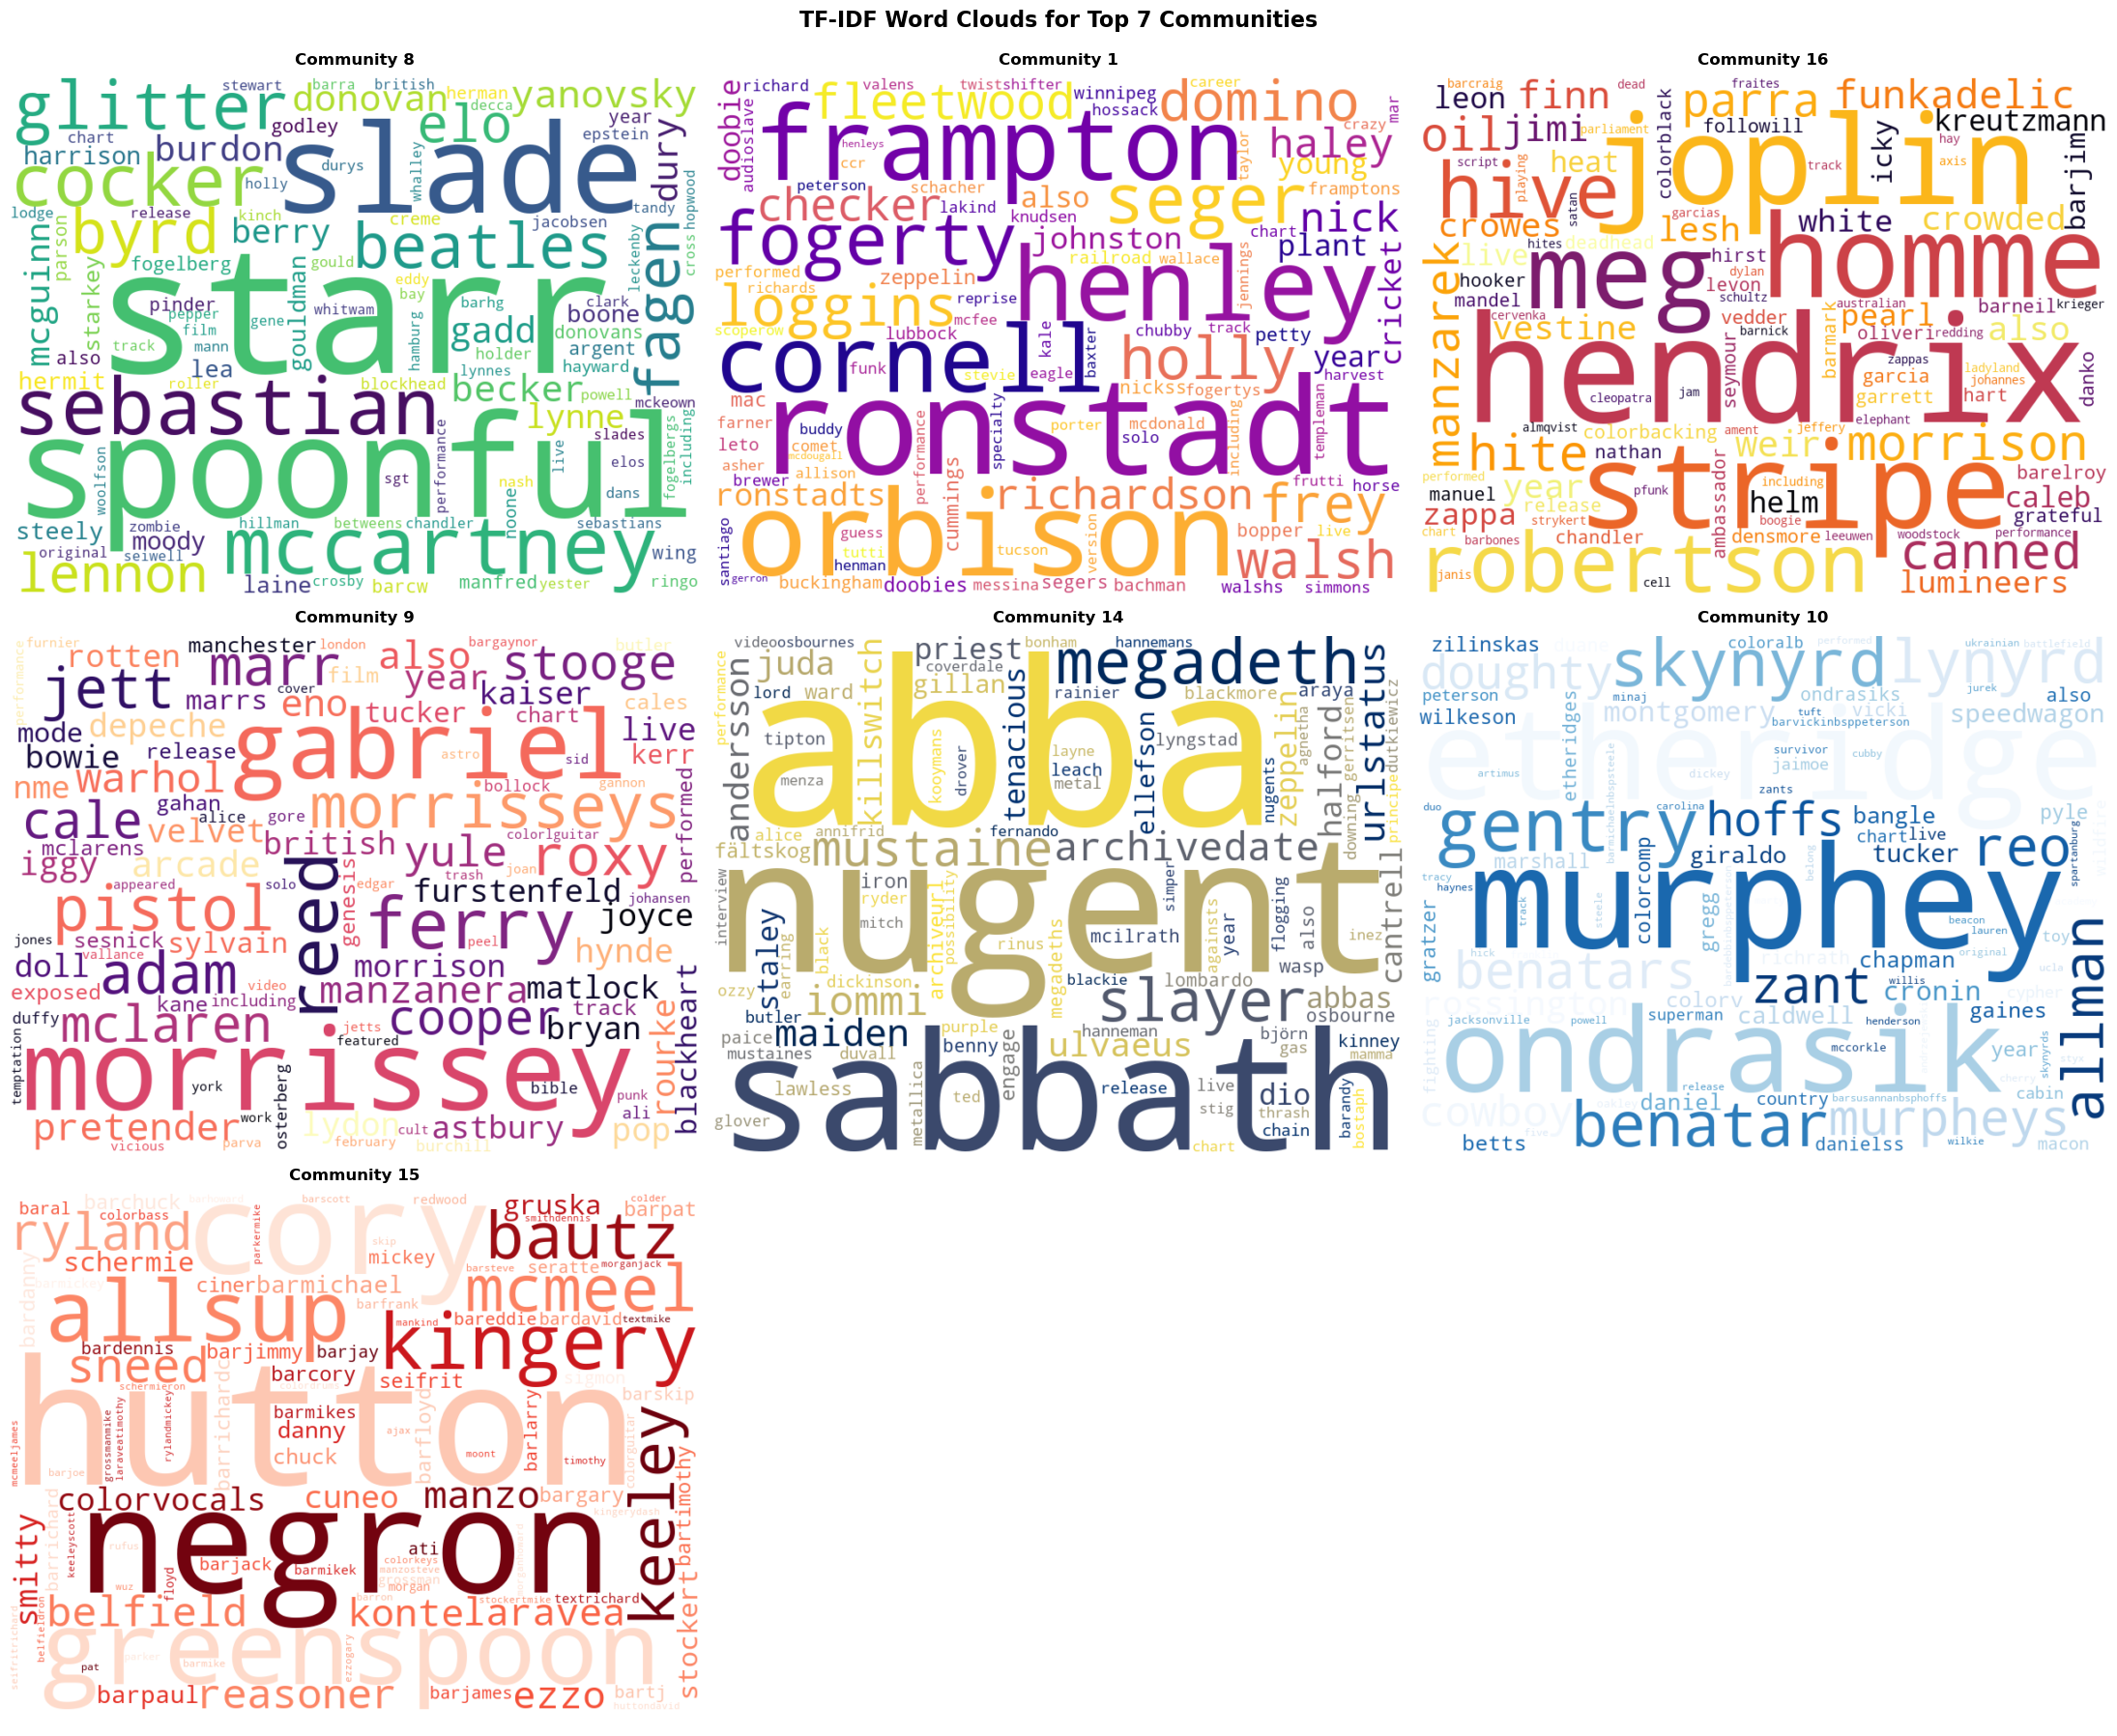

In [43]:
# For genres
create_tfidf_wordclouds(
    genre_tf_idf,
    top_genres,
    'TF-IDF Word Clouds for Top 7 Genres'
)

# For communities
create_tfidf_wordclouds(
    community_tf_idf,
    top_communities,
    'TF-IDF Word Clouds for Top 7 Communities'
)

### **Use the matrix $D$ (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.**

TODO

# **Part 4: Sentiment of the artists and communities**

### **Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.**

##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Download the LabMT wordlist. It’s available as supplementary material from Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter (Data Set S1). Describe briefly how the list was generated.**

They collected a large corpus of words from Twitter and selected the top 10,000 most frequently used. Then these selected list of words are rated by humans on Amazon Mechanical Turk on an integer scale from 1 to 9.

In [44]:
import pandas as pd
import urllib.request

url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

try:
    # Download the file
    urllib.request.urlretrieve(url, "labMT_wordlist.txt")
    
    # Load it as a dataframe
    labmt = pd.read_csv("labMT_wordlist.txt", sep='\t', skiprows=2)
    print(f"  Loaded {len(labmt)} words")
    
    # Create dictionary: word -> happiness score
    labmt_dict = dict(zip(labmt['word'].str.lower(), labmt['happiness_average']))
    
except Exception as e:
    print(f"✗ Error: {e}")

  Loaded 10222 words


##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Based on the LabMT word list, write a function that calculates sentiment given a list of tokens (the tokens should be lower case, etc).**

In [45]:
def calculate_sentiment(tokens, sentiment_dict=labmt_dict):
    # Filter tokens that exist in our sentiment dictionary
    scored_tokens = [sentiment_dict[token] for token in tokens if token in sentiment_dict]
    
    # Return average, or None if no tokens matched
    if scored_tokens:
        return sum(scored_tokens) / len(scored_tokens)
    else:
        return None

##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Iterate over the nodes in your network, tokenize each page, and calculate sentiment every single page. Now you have sentiment as a new nodal property.**

In [63]:
import re
from collections import Counter

# Counter for statistics
sentiments_calculated = 0
sentiments_failed = 0
all_sentiments = []

# Iterate through all nodes
for node in network.nodes():
    # Get the page content
    content = network.nodes[node].get('content', '')
    
    if not content:
        network.nodes[node]['sentiment'] = None
        sentiments_failed += 1
        continue
    
    content = load_content(content)
    
    # Clean and tokenize
    tokens = clean_and_tokenize(content)
    
    # Calculate sentiment
    sentiment = calculate_sentiment(tokens)
    
    # Store as node attribute
    network.nodes[node]['sentiment'] = sentiment
    
    if sentiment is not None:
        sentiments_calculated += 1
        all_sentiments.append(sentiment)
    else:
        sentiments_failed += 1

print(f"{'Sentiments calculated:':<30}{sentiments_calculated}")
print(f"{'Failed (no matching words):':<30}{sentiments_failed}")
print(f"{'Total nodes:':<30}{network.number_of_nodes()}")

Sentiments calculated:        457
Failed (no matching words):   27
Total nodes:                  484


##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Calculate the average sentiment across all the pages. Also calculate the median, variance, 25th percentile, 75th percentile.**

In [64]:
import numpy as np

# Calculate statistics
sentiment_mean = np.mean(all_sentiments)
sentiment_median = np.median(all_sentiments)
sentiment_variance = np.var(all_sentiments)
sentiment_std = np.std(all_sentiments)
sentiment_25th = np.percentile(all_sentiments, 25)
sentiment_75th = np.percentile(all_sentiments, 75)
sentiment_min = np.min(all_sentiments)
sentiment_max = np.max(all_sentiments)

print("Sentiment Statistics:")
print(f"{'Mean:':<28}{sentiment_mean:.2f}")
print(f"{'Median:':<28}{sentiment_median:.2f}")
print(f"{'Variance:':<28}{sentiment_variance:.2f}")
print(f"{'Std Deviation:':<28}{sentiment_std:.2f}")
print(f"{'25th Percentile (Q1):':<28}{sentiment_25th:.2f}")
print(f"{'75th Percentile (Q3):':<28}{sentiment_75th:.2f}")
print(f"{'IQR (Q3-Q1):':<28}{sentiment_75th - sentiment_25th:.2f}")
print(f"{'Minimum:':<28}{sentiment_min:.2f}")
print(f"{'Maximum:':<28}{sentiment_max:.2f}")
print(f"{'Range:':<28}{sentiment_max - sentiment_min:.2f}")
print(f"{'Sample size:':<28}{len(all_sentiments)} pages")

Sentiment Statistics:
Mean:                       5.83
Median:                     5.84
Variance:                   0.02
Std Deviation:              0.13
25th Percentile (Q1):       5.77
75th Percentile (Q3):       5.91
IQR (Q3-Q1):                0.14
Minimum:                    5.16
Maximum:                    6.27
Range:                      1.12
Sample size:                457 pages


##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Remember histograms? Create a histogram of all of the artists’s associated page-sentiments. (And make it a nice histogram - use your histogram making skills from Week 2). Add the mean, median, ect from above to your plot.**

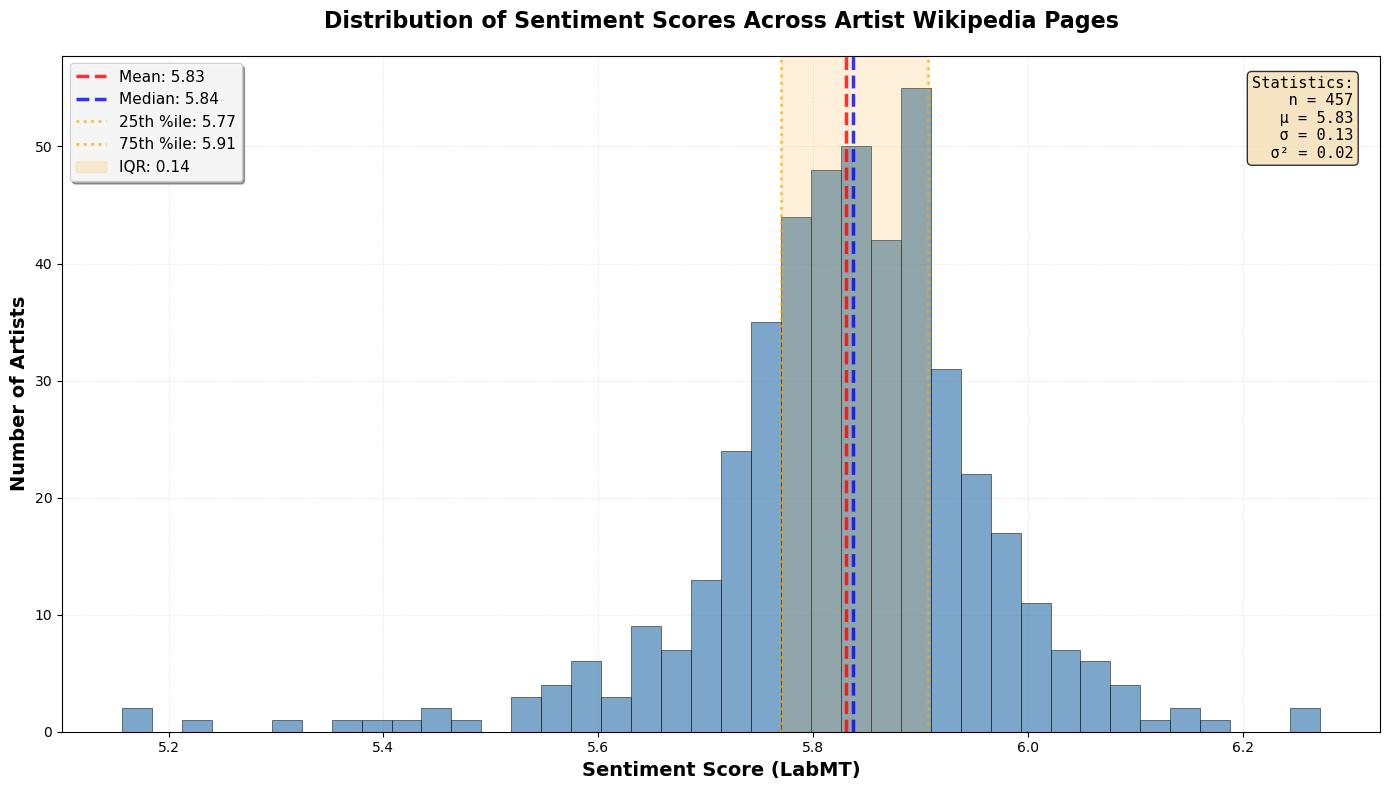

In [62]:
import matplotlib.pyplot as plt

# Set style for a beautiful plot
plt.rcParams['figure.facecolor'] = 'white'

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create histogram
n, bins, patches = ax.hist(all_sentiments, bins=40, alpha=0.7, color='steelblue',
                        edgecolor='black', linewidth=0.5, density=False)


# Add vertical lines for statistics
ax.axvline(sentiment_mean, color='red', linestyle='--', linewidth=2.5,
        label=f'Mean: {sentiment_mean:.2f}', alpha=0.8)
ax.axvline(sentiment_median, color='blue', linestyle='--', linewidth=2.5,
        label=f'Median: {sentiment_median:.2f}', alpha=0.8)
ax.axvline(sentiment_25th, color='orange', linestyle=':', linewidth=2,
        label=f'25th %ile: {sentiment_25th:.2f}', alpha=0.7)
ax.axvline(sentiment_75th, color='orange', linestyle=':', linewidth=2,
        label=f'75th %ile: {sentiment_75th:.2f}', alpha=0.7)

# Shade the IQR region
ax.axvspan(sentiment_25th, sentiment_75th, alpha=0.15, color='orange',
        label=f'IQR: {sentiment_75th - sentiment_25th:.2f}')

# Labels and title
ax.set_xlabel('Sentiment Score (LabMT)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Artists', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Sentiment Scores Across Artist Wikipedia Pages',
                fontsize=16, fontweight='bold', pad=20)

# Add legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.9, shadow=True)

# Add text box with statistics
textstr = '\n'.join([
        f'Statistics:',
        f'  n = {len(all_sentiments)}',
        f'  μ = {sentiment_mean:.2f}',
        f'  σ = {sentiment_std:.2f}',
        f'  σ² = {sentiment_variance:.2f}',
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props,
        family='monospace')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

##### **Corresponding text from Week 8 Part 1 exercise:** #####

* **Who are the 10 artists with happiest and saddest pages?**

In [49]:
# Create a list of (artist, sentiment) tuples for all artists with valid sentiment
artist_sentiments = []
for node in network.nodes():
    sentiment = network.nodes[node]['sentiment']
    if sentiment is not None:
        artist_sentiments.append((node, sentiment))

# Sort by sentiment
artist_sentiments.sort(key=lambda x: x[1])

# Get top 10 saddest and happiest
saddest_10 = artist_sentiments[:10]
happiest_10 = artist_sentiments[-10:][::-1]

print("Top 10 Saddest Artists")
for i, (artist, sentiment) in enumerate(saddest_10, 1):
    print(f"{i:2d}. {artist:40s} - Sentiment: {sentiment:.2f}")

print("\nTop 10 Happiest Artists")
for i, (artist, sentiment) in enumerate(happiest_10, 1):
    print(f"{i:2d}. {artist:40s} - Sentiment: {sentiment:.2f}")

# Calculate difference
if len(happiest_10) > 0 and len(saddest_10) > 0:
    sentiment_range = happiest_10[0][1] - saddest_10[0][1]
    print(f"\nSentiment range (happiest - saddest): {sentiment_range:.2f}")

Top 10 Saddest Artists
 1. poison (american band)|poison            - Sentiment: 5.16
 2. everclear (band)|everclear               - Sentiment: 5.17
 3. garbage (band)|garbage                   - Sentiment: 5.23
 4. keane (band)|keane                       - Sentiment: 5.32
 5. anthrax (american band)|anthrax          - Sentiment: 5.36
 6. traffic (band)|traffic                   - Sentiment: 5.40
 7. 311 (band)|311                           - Sentiment: 5.43
 8. ghost (swedish band)|ghost               - Sentiment: 5.44
 9. hole (band)|hole                         - Sentiment: 5.45
10. 38 special (band)|.38 special            - Sentiment: 5.49

Top 10 Happiest Artists
 1. steppenwolf (band)|steppenwolf           - Sentiment: 6.27
 2. journey (band)|journey                   - Sentiment: 6.25
 3. queen (band)|queen                       - Sentiment: 6.16
 4. pixies (band)|pixies                     - Sentiment: 6.16
 5. live (band)|live                         - Sentiment: 6.15
 6. yes

### **Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?**

##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **Last week we calculated the stuctural communities of the graph. For this exercise, we use those communities (just the 10 largest ones, or all your communities if you have fewer than 10). Specifically, you should calculate the average the average sentiment of the nodes in each community to find a community level sentiment.?**

In [54]:
# Calculate average sentiment for each community
community_sentiments = {}

for comm_id in top_communities:
    members = louvain_dict[comm_id]
    
    # Get sentiments for all members of this community
    sentiments = []
    for artist in members:
        if artist in network.nodes():
            sentiment = network.nodes[artist].get('sentiment', None)
            if sentiment is not None:
                sentiments.append(sentiment)
    
    # Calculate average
    if sentiments:
        avg_sentiment = np.mean(sentiments)
        community_sentiments[comm_id] = {
            'avg_sentiment': avg_sentiment,
            'size': len(members),
            'sentiment_count': len(sentiments),
            'members': members
        }
    else:
        print(f"\nCommunity {comm_id}:")
        print(f"  Size: {len(members)} members")
        print(f"  No sentiment data available")

for comm_id, stats in community_sentiments.items():
    print(f"\nCommunity {comm_id}:")
    print(f"  Size: {stats['size']} members")
    print(f"  Sentiment data for {stats['sentiment_count']} members")
    print(f"  Average Sentiment: {stats['avg_sentiment']:.2f}")


Community 8:
  Size: 29 members
  Sentiment data for 29 members
  Average Sentiment: 5.82

Community 1:
  Size: 28 members
  Sentiment data for 28 members
  Average Sentiment: 5.85

Community 16:
  Size: 26 members
  Sentiment data for 26 members
  Average Sentiment: 5.85

Community 9:
  Size: 25 members
  Sentiment data for 25 members
  Average Sentiment: 5.84

Community 14:
  Size: 17 members
  Sentiment data for 17 members
  Average Sentiment: 5.79

Community 10:
  Size: 13 members
  Sentiment data for 13 members
  Average Sentiment: 5.88

Community 15:
  Size: 1 members
  Sentiment data for 1 members
  Average Sentiment: 5.80


##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **Name each community by its three most connected bands. (Or feed the list of bands in each community and ask the LLM to come up with a good name for the community).?**

In [55]:
# Name each community by the 3 most connected bands
community_names = {}

print("Naming Top Communities Based on Most Connected Bands:")

for comm_id in top_communities:
    if comm_id not in community_sentiments:
        continue
    
    members = community_sentiments[comm_id]['members']
    
    # Calculate degree centrality within the community (subgraph)
    community_subgraph = network.subgraph(members)
    degrees = dict(community_subgraph.degree())
    
    # Sort by degree and get top 3 (or fewer if community is small)
    top_3 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:3]
    top_3_names = [name for name, degree in top_3]
    
    # Create a descriptive name (handle communities with fewer than 3 members)
    if len(top_3_names) >= 3:
        community_name = f"{top_3_names[0]}, {top_3_names[1]}, {top_3_names[2]}"
    elif len(top_3_names) == 2:
        community_name = f"{top_3_names[0]}, {top_3_names[1]}"
    elif len(top_3_names) == 1:
        community_name = top_3_names[0]
    else:
        community_name = f"Community {comm_id}"
    
    community_names[comm_id] = {
        'short_name': community_name,
        'top_bands': top_3_names,
        'degrees': [degree for name, degree in top_3]
    }
    
    print(f"\nCommunity {comm_id}:")
    print(f"  Name: {community_name}")

Naming Top Communities Based on Most Connected Bands:

Community 8:
  Name: the beatles, the lovin' spoonful, the animals

Community 1:
  Name: neil young, little richard, linda ronstadt

Community 16:
  Name: pearl jam, the doors, jimi hendrix

Community 9:
  Name: sex pistols, iggy pop, the smiths

Community 14:
  Name: iron maiden, black sabbath, slayer

Community 10:
  Name: lynyrd skynyrd, pat benatar, charlie daniels

Community 15:
  Name: three dog night


##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **What are the three happiest communities? (or the two happiest if you have 5 or fewer communities)**

In [56]:
# Sort communities by sentiment
sorted_communities = sorted(community_sentiments.items(), 
                        key=lambda x: x[1]['avg_sentiment'])

# Determine how many to show (3 if >5 communities, 2 if ≤5)
num_to_show = 3

saddest_communities = sorted_communities[:num_to_show]
happiest_communities = sorted_communities[-num_to_show:][::-1]

print(f"Top {num_to_show} saddest communities")

for i, (comm_id, data) in enumerate(saddest_communities, 1):
    name = community_names[comm_id]['short_name']
    sentiment = data['avg_sentiment']
    size = data['size']
    print(f"\n{i}. Community {comm_id}: {name}")
    print(f"   Average Sentiment: {sentiment:.2f}")
    print(f"   Size: {size} members")
    print(f"   Difference from overall mean: {sentiment - sentiment_mean:+.2f}")


Top 3 saddest communities

1. Community 14: iron maiden, black sabbath, slayer
   Average Sentiment: 5.79
   Size: 17 members
   Difference from overall mean: -0.04

2. Community 15: three dog night
   Average Sentiment: 5.80
   Size: 1 members
   Difference from overall mean: -0.03

3. Community 8: the beatles, the lovin' spoonful, the animals
   Average Sentiment: 5.82
   Size: 29 members
   Difference from overall mean: -0.01


##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **What are the three saddest communities? (or the two happiest if you have 5 or fewer communities)**

In [57]:
print(f"\nTop {num_to_show} happiest communities")

for i, (comm_id, data) in enumerate(happiest_communities, 1):
    name = community_names[comm_id]['short_name']
    sentiment = data['avg_sentiment']
    size = data['size']
    print(f"\n{i}. Community {comm_id}: {name}")
    print(f"   Average Sentiment: {sentiment:.2f}")
    print(f"   Size: {size} members")
    print(f"   Difference from overall mean: {sentiment - sentiment_mean:+.2f}")


Top 3 happiest communities

1. Community 10: lynyrd skynyrd, pat benatar, charlie daniels
   Average Sentiment: 5.88
   Size: 13 members
   Difference from overall mean: +0.05

2. Community 1: neil young, little richard, linda ronstadt
   Average Sentiment: 5.85
   Size: 28 members
   Difference from overall mean: +0.02

3. Community 16: pearl jam, the doors, jimi hendrix
   Average Sentiment: 5.85
   Size: 26 members
   Difference from overall mean: +0.01


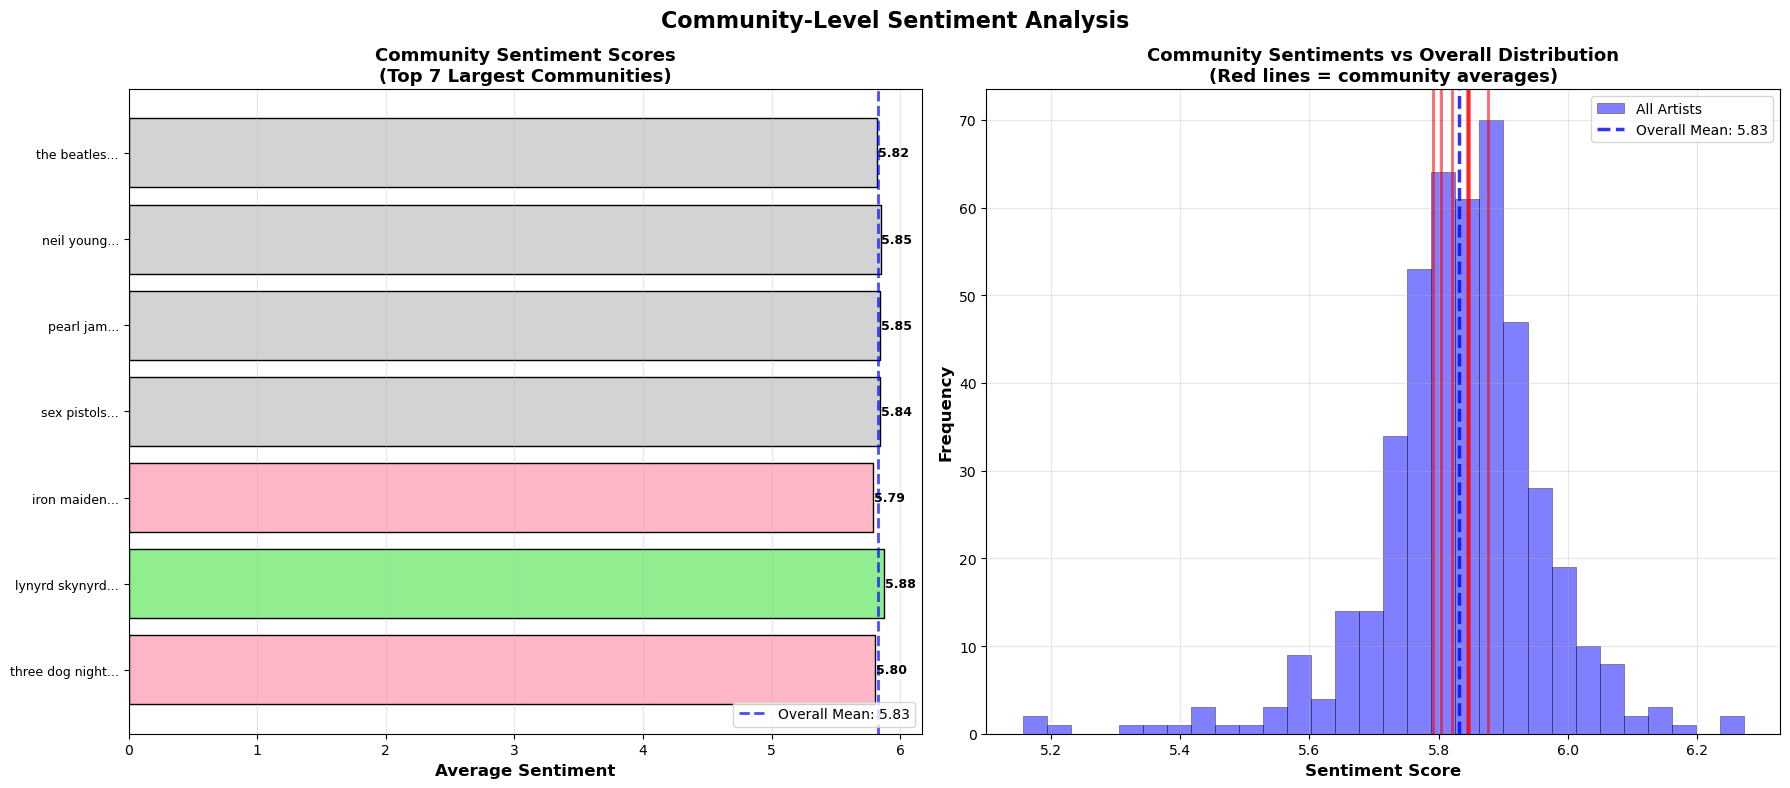

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Bar chart of community sentiments
comm_ids = []
comm_sentiments = []
comm_names_short = []

for comm_id in top_communities:
    if comm_id in community_sentiments:
        comm_ids.append(f"C{comm_id}")
        comm_sentiments.append(community_sentiments[comm_id]['avg_sentiment'])
        # Shorten name for display
        full_name = community_names[comm_id]['short_name']
        short_name = full_name.split(',')[0] + "..."  # Just first band + "..."
        comm_names_short.append(short_name)

# Color code bars
colors = []
for sent in comm_sentiments:
    if sent > sentiment_mean + 0.02:
        colors.append('#90EE90')  # Green for above average
    elif sent < sentiment_mean - 0.02:
        colors.append('#FFB6C6')  # Red for below average
    else:
        colors.append('#D3D3D3')  # Gray for near average

y_pos = range(len(comm_ids))
bars = ax1.barh(y_pos, comm_sentiments, color=colors, edgecolor='black', linewidth=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(comm_names_short, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Average Sentiment', fontsize=12, fontweight='bold')
ax1.set_title(f'Community Sentiment Scores\n(Top {len(top_communities)} Largest Communities)',
            fontsize=13, fontweight='bold')
ax1.axvline(sentiment_mean, color='blue', linestyle='--', linewidth=2,
            label=f'Overall Mean: {sentiment_mean:.2f}', alpha=0.7)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, sent) in enumerate(zip(bars, comm_sentiments)):
    ax1.text(sent + 0.005, i, f'{sent:.2f}', va='center', fontsize=9, fontweight='bold')

# Right plot: Distribution comparison
ax2.hist(all_sentiments, bins=30, alpha=0.5, color='blue', label='All Artists',
        edgecolor='black', linewidth=0.5)

# Overlay community average sentiments as vertical lines
for comm_id, sent in zip(comm_ids, comm_sentiments):
    ax2.axvline(sent, color='red', linestyle='-', linewidth=2, alpha=0.6)

ax2.axvline(sentiment_mean, color='blue', linestyle='--', linewidth=2.5,
            label=f'Overall Mean: {sentiment_mean:.2f}', alpha=0.8)
ax2.set_xlabel('Sentiment Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Community Sentiments vs Overall Distribution\n(Red lines = community averages)',
            fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Community-Level Sentiment Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **Do these results confirm what you can learn about each community by comparing to the genres, checking out the word-clouds for each community, and reading the wiki-pages?**

TODO

##### **Corresponding text from Week 8 Part 2 exercise:** #####

* **Compare the sentiment of the happiest and saddest communities to the overall (entire network) distribution of sentiment that you calculated in the previous exercise. Are the communities very differenct from the average? Or do you find the sentiment to be quite similar across all of the communities?**

TODO